# Reproducing the Phonon-Filter Figures

This notebook regenerates every Python-generated figure from
*Theoretical Design of Phonon Filters for Quantum Sensing and Qubits*
(Krisshnamurthi, Hussien, Lubner, Griffin).

The calculation combines the **Acoustic Mismatch Model** (angular, polarization-
resolved interface transmission) with **Tamura mass-difference scattering** in the
SiGe layer (a frequency-dependent mean free path), solved through a phonon
**radiative-transport** treatment using `PythonicDISORT`. The only primary inputs
are three DFT phonon density-of-states files for the SiGe phases.


## Setup

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline
import numpy as np
import phonon_filters as pf
from phonon_filters import dataio, scattering, transport, figures

OUT = 'figures'  # generated figures are also saved here

## Inputs: DFT density of states and the SiGe mean free path

We read the three SiGe-phase DOS files, average them onto a common log-spaced
frequency grid, and convert to a mass-difference mean free path $\Lambda(\nu)$ via
the **Tamura** model. The alloy scattering rate is Rayleigh-like,
$\tau^{-1}(\omega)=\tfrac{\pi}{6}\,V_0\,g\,\omega^2 D(\omega)$, with the
mass-fluctuation factor $g=\sum_i x_i\big((m_i-\bar m)/\bar m\big)^2$, so the mean
free path is $\Lambda(\omega)=v(\omega)\,\tau(\omega)$. Truncation keeps the
physical sub-3-THz range.

*Tamura, Phys. Rev. B **27**, 858 (1983), [doi:10.1103/PhysRevB.27.858](https://doi.org/10.1103/PhysRevB.27.858).*

In [2]:
nu_THz, _, dos = dataio.read_dos_average(dataio.default_dos_paths(), num_points=110)
_, mfp = scattering.mass_difference_mfp_dft(nu_THz, dos)
nu_tr_Hz, mfp_tr, _ = dataio.truncate_mfp(nu_THz * 1e12, mfp, dos)
nu_GHz = nu_tr_Hz / 1e9
elemental = pf.load_elemental_properties()
print(f'{len(nu_GHz)} frequency points from {nu_GHz.min():.1f} to {nu_GHz.max():.0f} GHz')

87 frequency points from 5.0 to 2825 GHz


## Fig. 2 - Cumulative transmittance

The angle-resolved **acoustic-mismatch** (AMM) transmission of the Si/SiGe/Al
stack, $\alpha(\mu)=1-R$ with $R=\big(\tfrac{Z_1\mu-Z_2\mu_t}{Z_1\mu+Z_2\mu_t}\big)^2$
and acoustic impedance $Z=\rho c$, is multiplied by the mass-difference
scattering transmittance spectrum (the phonon radiative-transport / EPRT solution
at each incidence angle). Curves are coloured by $\mu=\cos\theta$; LA solid, TA
dotted.

**Panel (a)** shades $\nu_p\ge 2\Delta/h$ for Al — the pair-breaking /
harmful-quasiparticle band, where the transmittance should be lowest.
**Panel (b)** reverses the stack and overlays the thermally populated DOS,
$f_{BE}(\nu,T)\,\mathrm{DoS}(\nu)$, at 0.05 / 0.5 / 5 K; at 50 mK the thermal
phonons sit where $\alpha\approx 1$, so cooling is preserved.

*AMM: Little, Can. J. Phys. **37**, 334 (1959); Swartz & Pohl, Rev. Mod. Phys.
**61**, 605 (1989). EPRT: Majumdar, J. Heat Transfer **115**, 7 (1993); Prasher,
Appl. Phys. Lett. **83**, 48 (2003).*

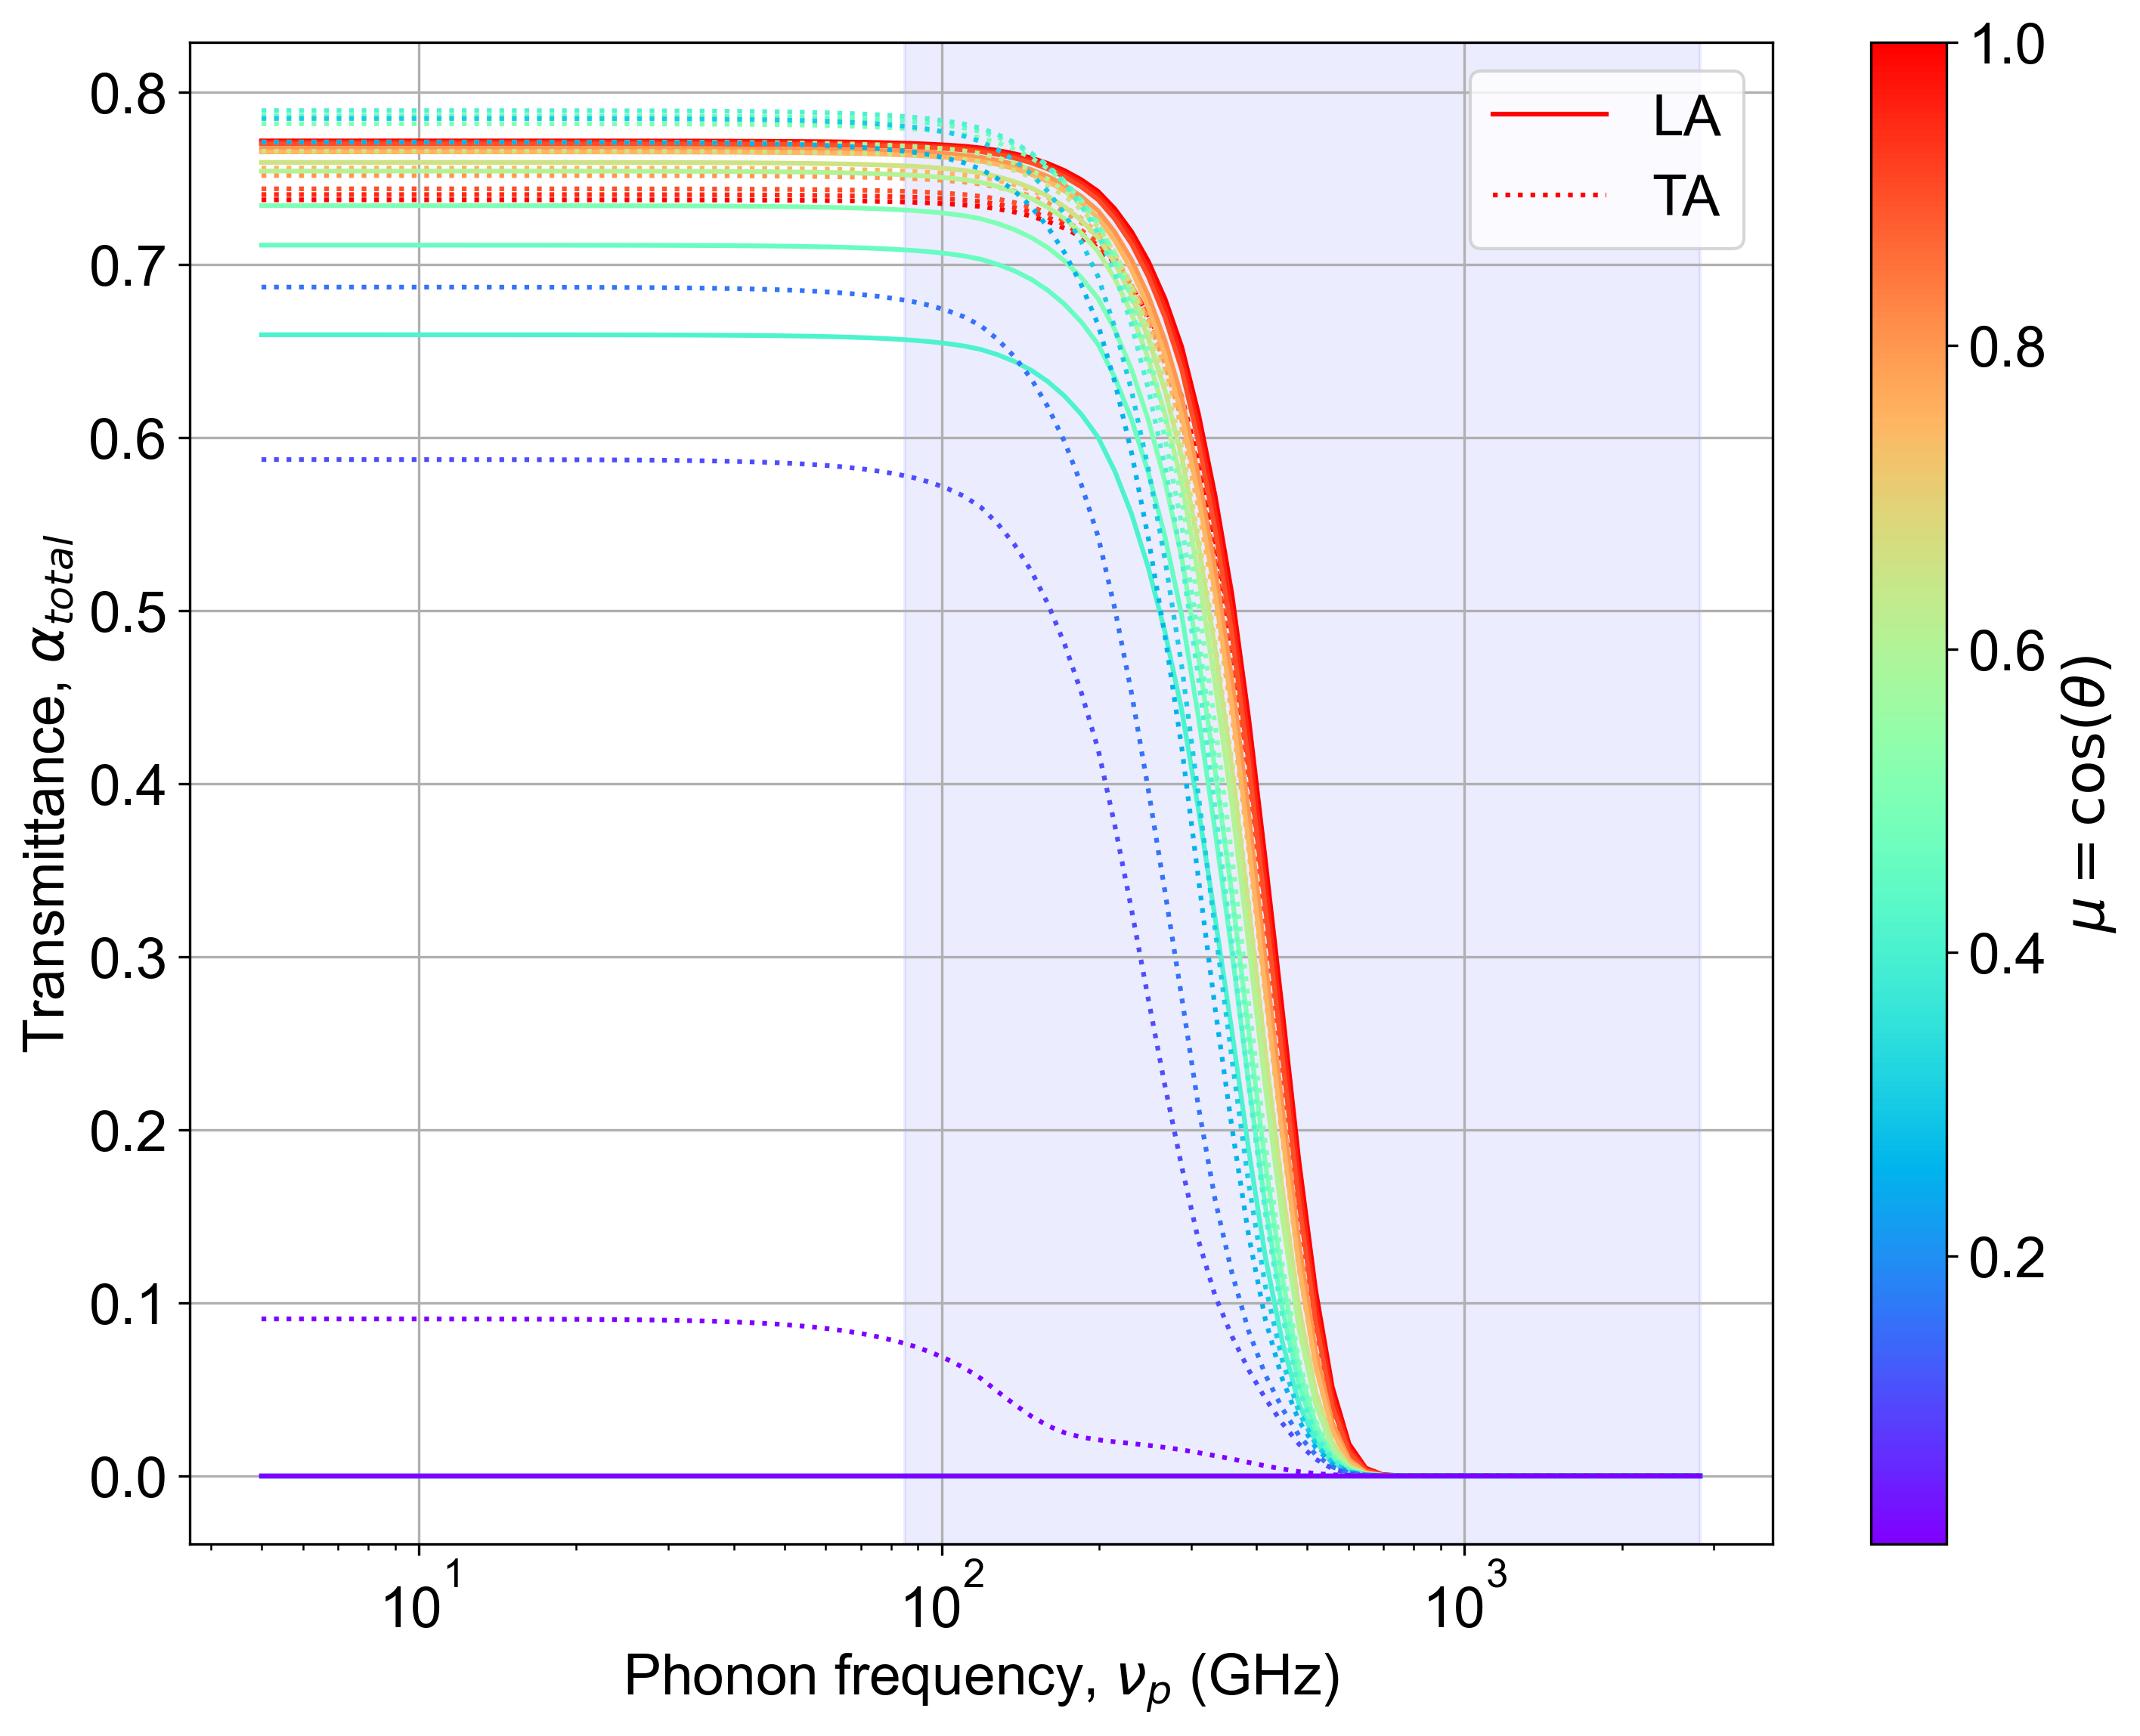

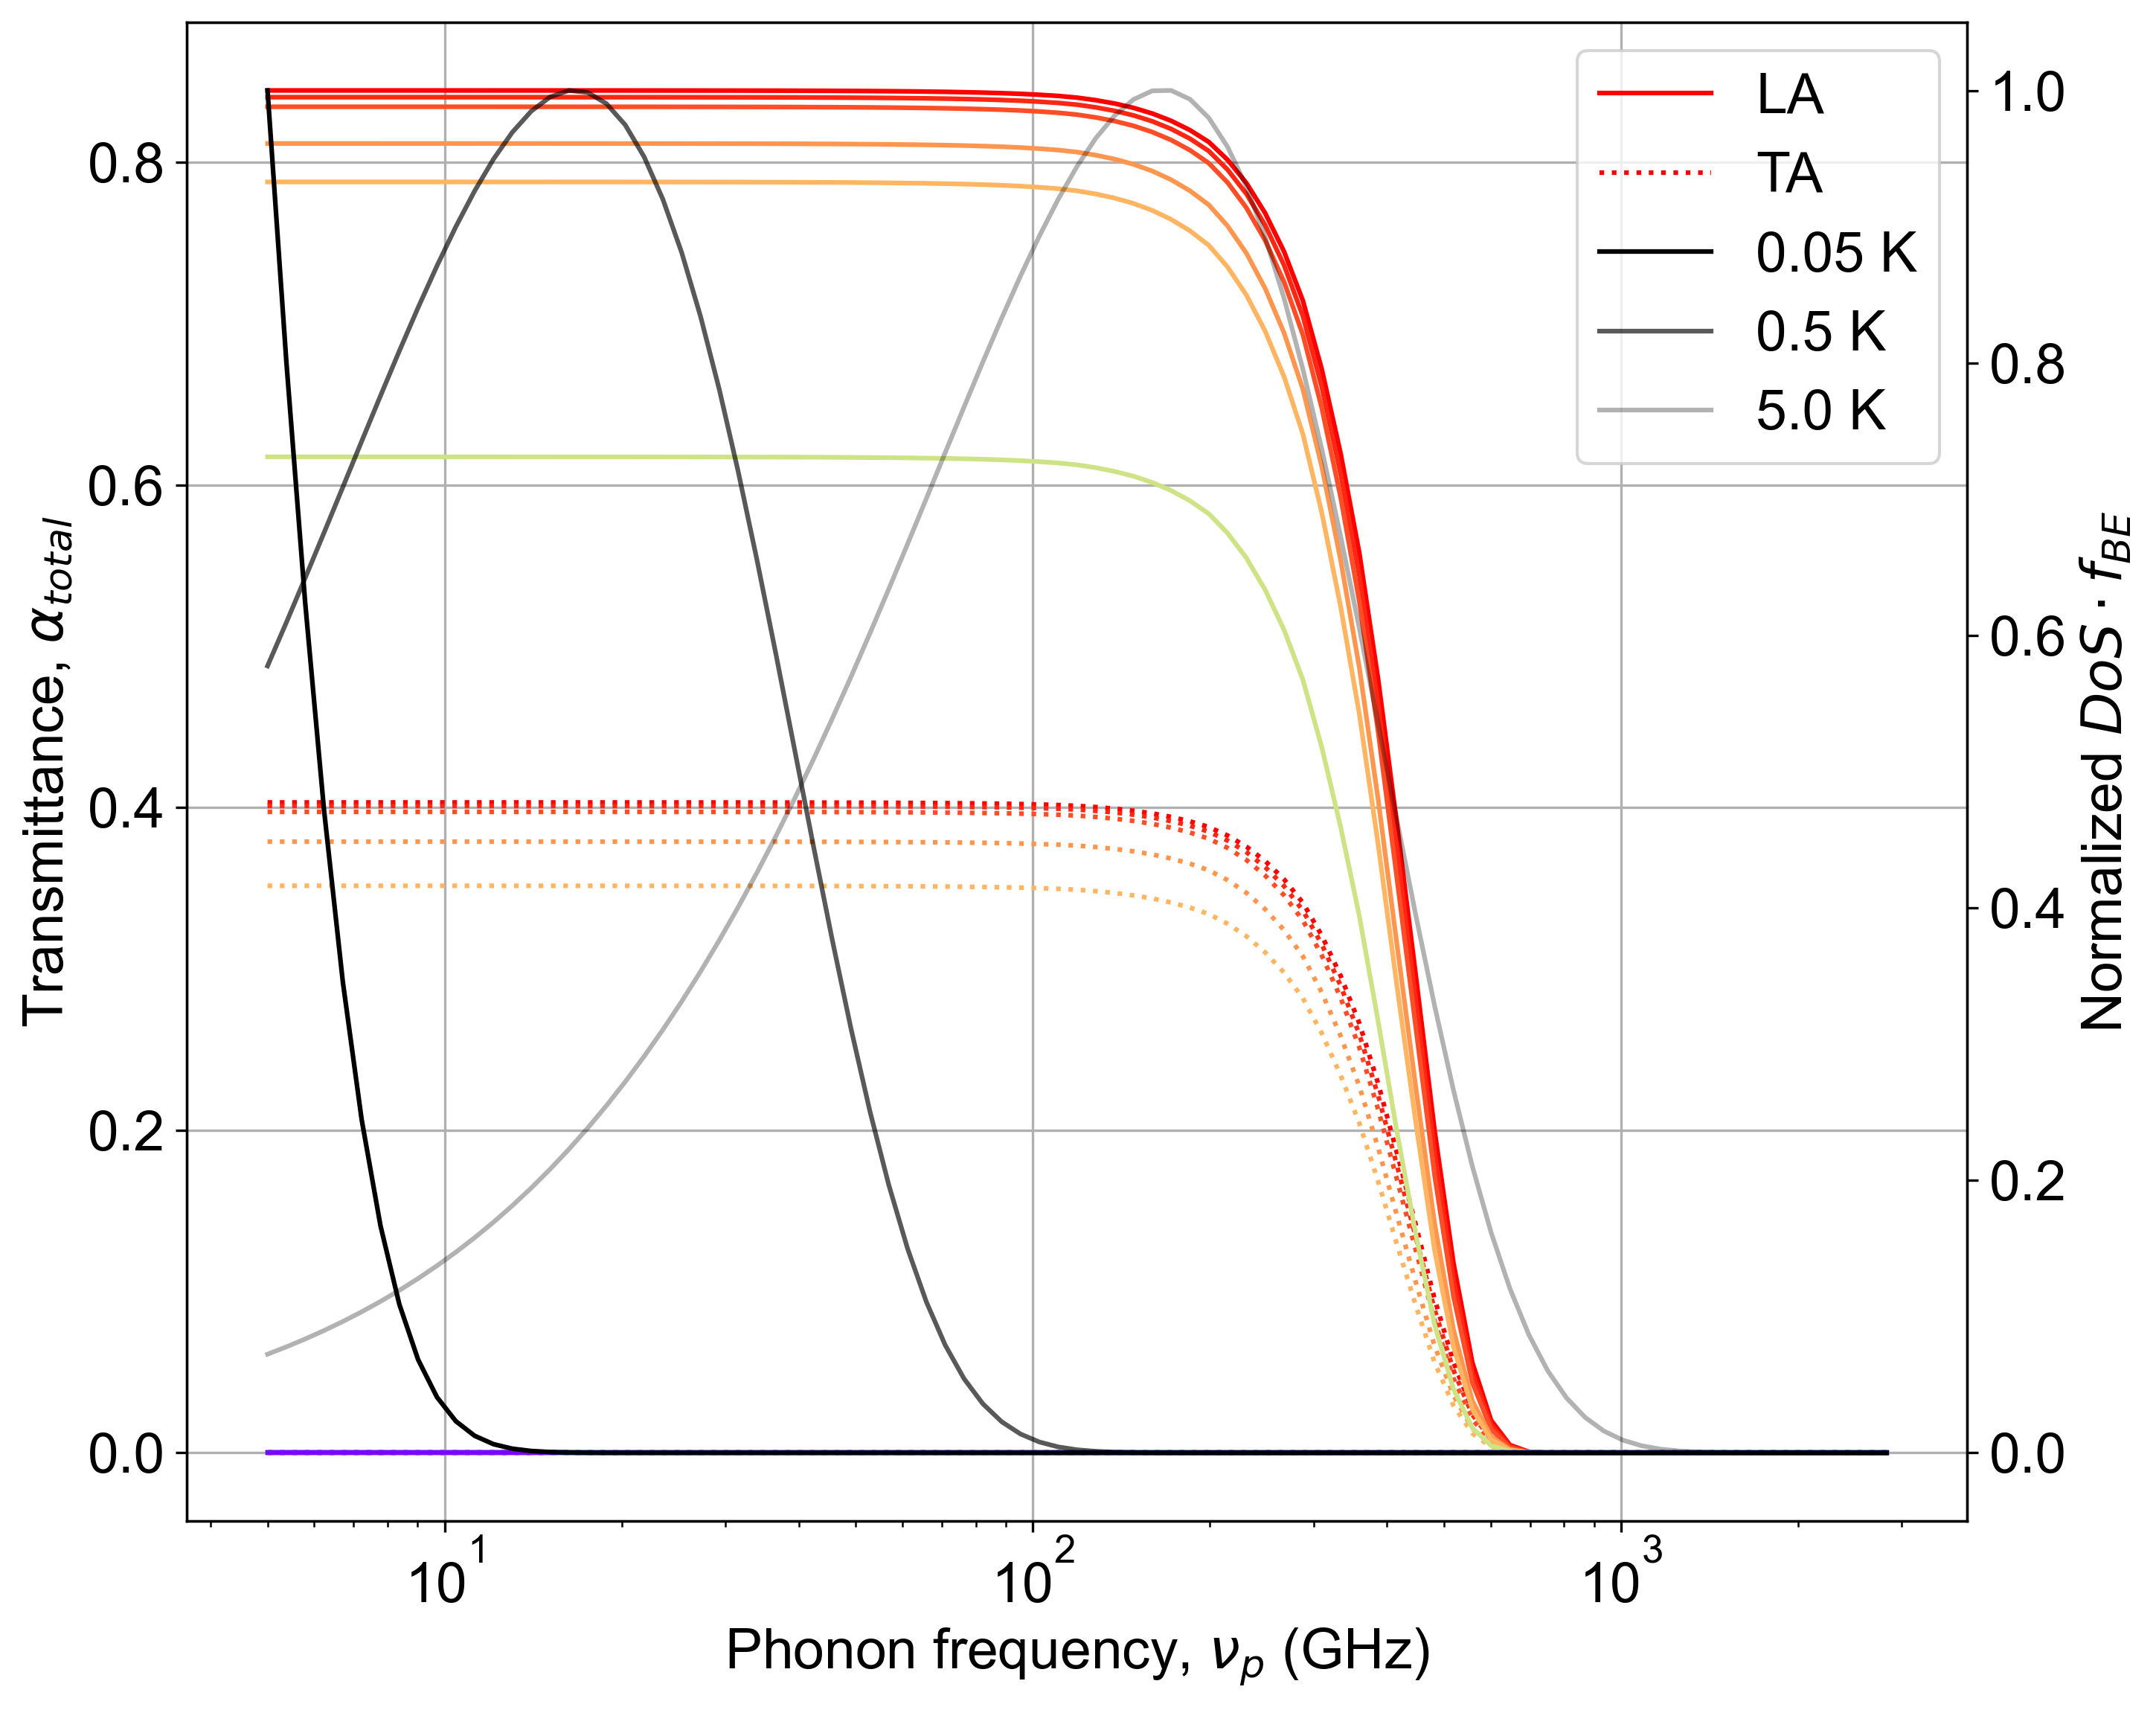

In [3]:
mu0_array = np.linspace(0.01, 1.0, 21)
scat_matrix = transport.transmittance_matrix(mfp_tr, mu0_array, L_um=1, ssa=0.5)

# Fig 2a: Si -> SiGe -> Al
figures.figure2(['Si', 'SiGe_avg', 'Al'], nu_GHz, mu0_array, scat_matrix,
                pf.MATERIALS, shade_high_freq=True, outdir=OUT, show=True, show_colorbar = True)

# Fig 2b: Al -> SiGe -> Si (with thermal-occupation overlay)
figures.figure2(['Al', 'SiGe_avg', 'Si'], nu_GHz, mu0_array, scat_matrix,
                pf.MATERIALS, elemental_data=elemental, temp_overlay=True,
                outdir=OUT, show=True, show_colorbar = False);

## Fig. 3 - Parameter sensitivity

Each model parameter is perturbed one at a time and the cumulative transmittance
recomputed, at three layer thicknesses. (See `../CORRECTIONS.md` for the fixes to
this analysis relative to the original code.)

In [4]:
base_params = {'m_Si': 28.08 * 1.66e-27, 'm_Ge': 72.08 * 1.66e-27, 'V0': 48e-30,
               'v_La': 6281, 'v_Ta': 2937, 'n_aly': 2, 'DoS': dos}
param_factors = {'m_Si': 0.25, 'm_Ge': 1.75, 'v_La': 1.75, 'v_Ta': 1.75, 'DoS': 1.75}
lengths = [0.1, 1.0, 10.0]
mu0_list = [ 1.0, 0.33, 0.66]
mu0 = 0.5
mu0_array1 = np.linspace(0.01, 1.0, 7)
stack, nu3 = figures.compute_sensitivity(
    nu_THz, dos, pf.MATERIALS, base_params, param_factors,
    lengths, mu0_array1, ['Si', 'SiGe_avg', 'Al'], 'L', ssa=0.5)

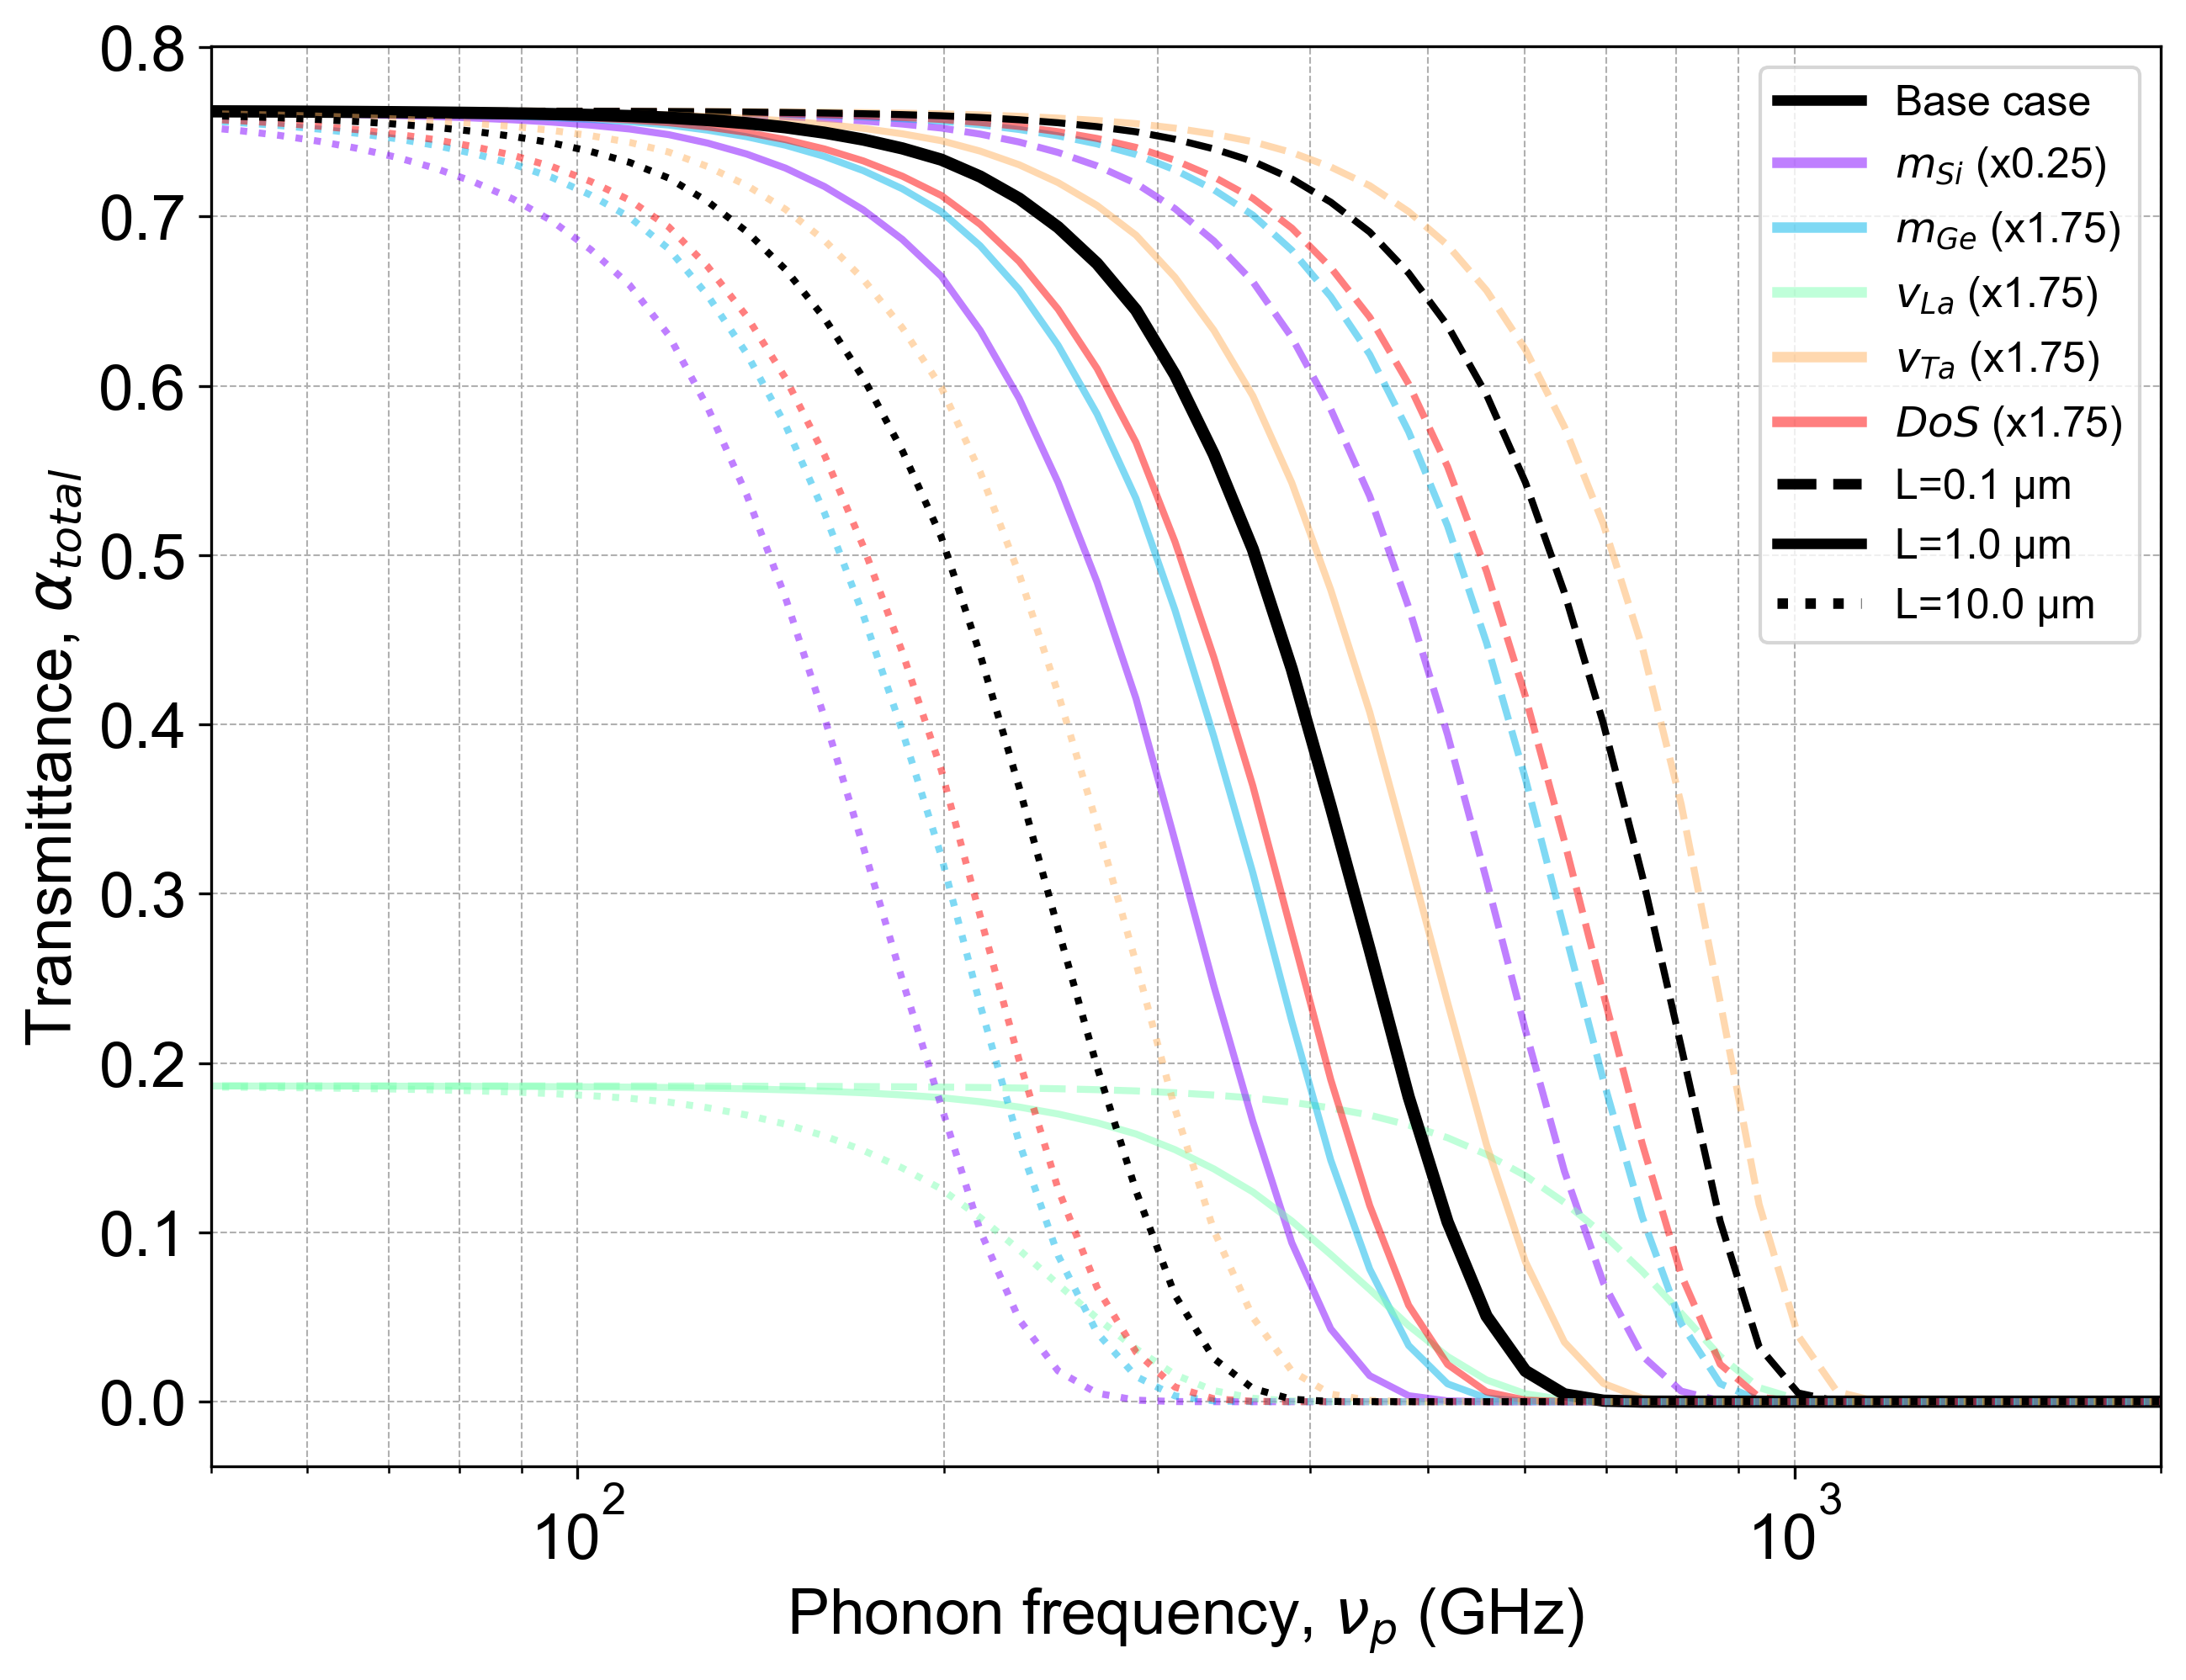

In [5]:
figures.figure3(stack, nu_GHz, mu0 = mu0_array1[-1],lengths = lengths, param_factors = param_factors,
            highlight_length=1.0, outdir=None, show=True)

## Figs. 4 and S8 — Single-scattering-albedo sweep

The scattering layer is solved as a phonon radiative-transport (EPRT) slab of
optical depth $\tau_p(\nu)=L/\Lambda(\nu)$ using the discrete-ordinates solver
**PythonicDISORT** with a Henyey–Greenstein phase function. Transmittance and
reflectance vs frequency for a $1\,\mu$m SiGe layer as the single-scattering
albedo $\sigma_p$ varies from strongly inelastic (0.001) to near-elastic
(0.999999).

*PythonicDISORT: Ho, J. Open Source Softw. **9**(103), 6442 (2024),
[doi:10.21105/joss.06442](https://doi.org/10.21105/joss.06442). Phase function:
Henyey & Greenstein, Astrophys. J. **93**, 70 (1941).*

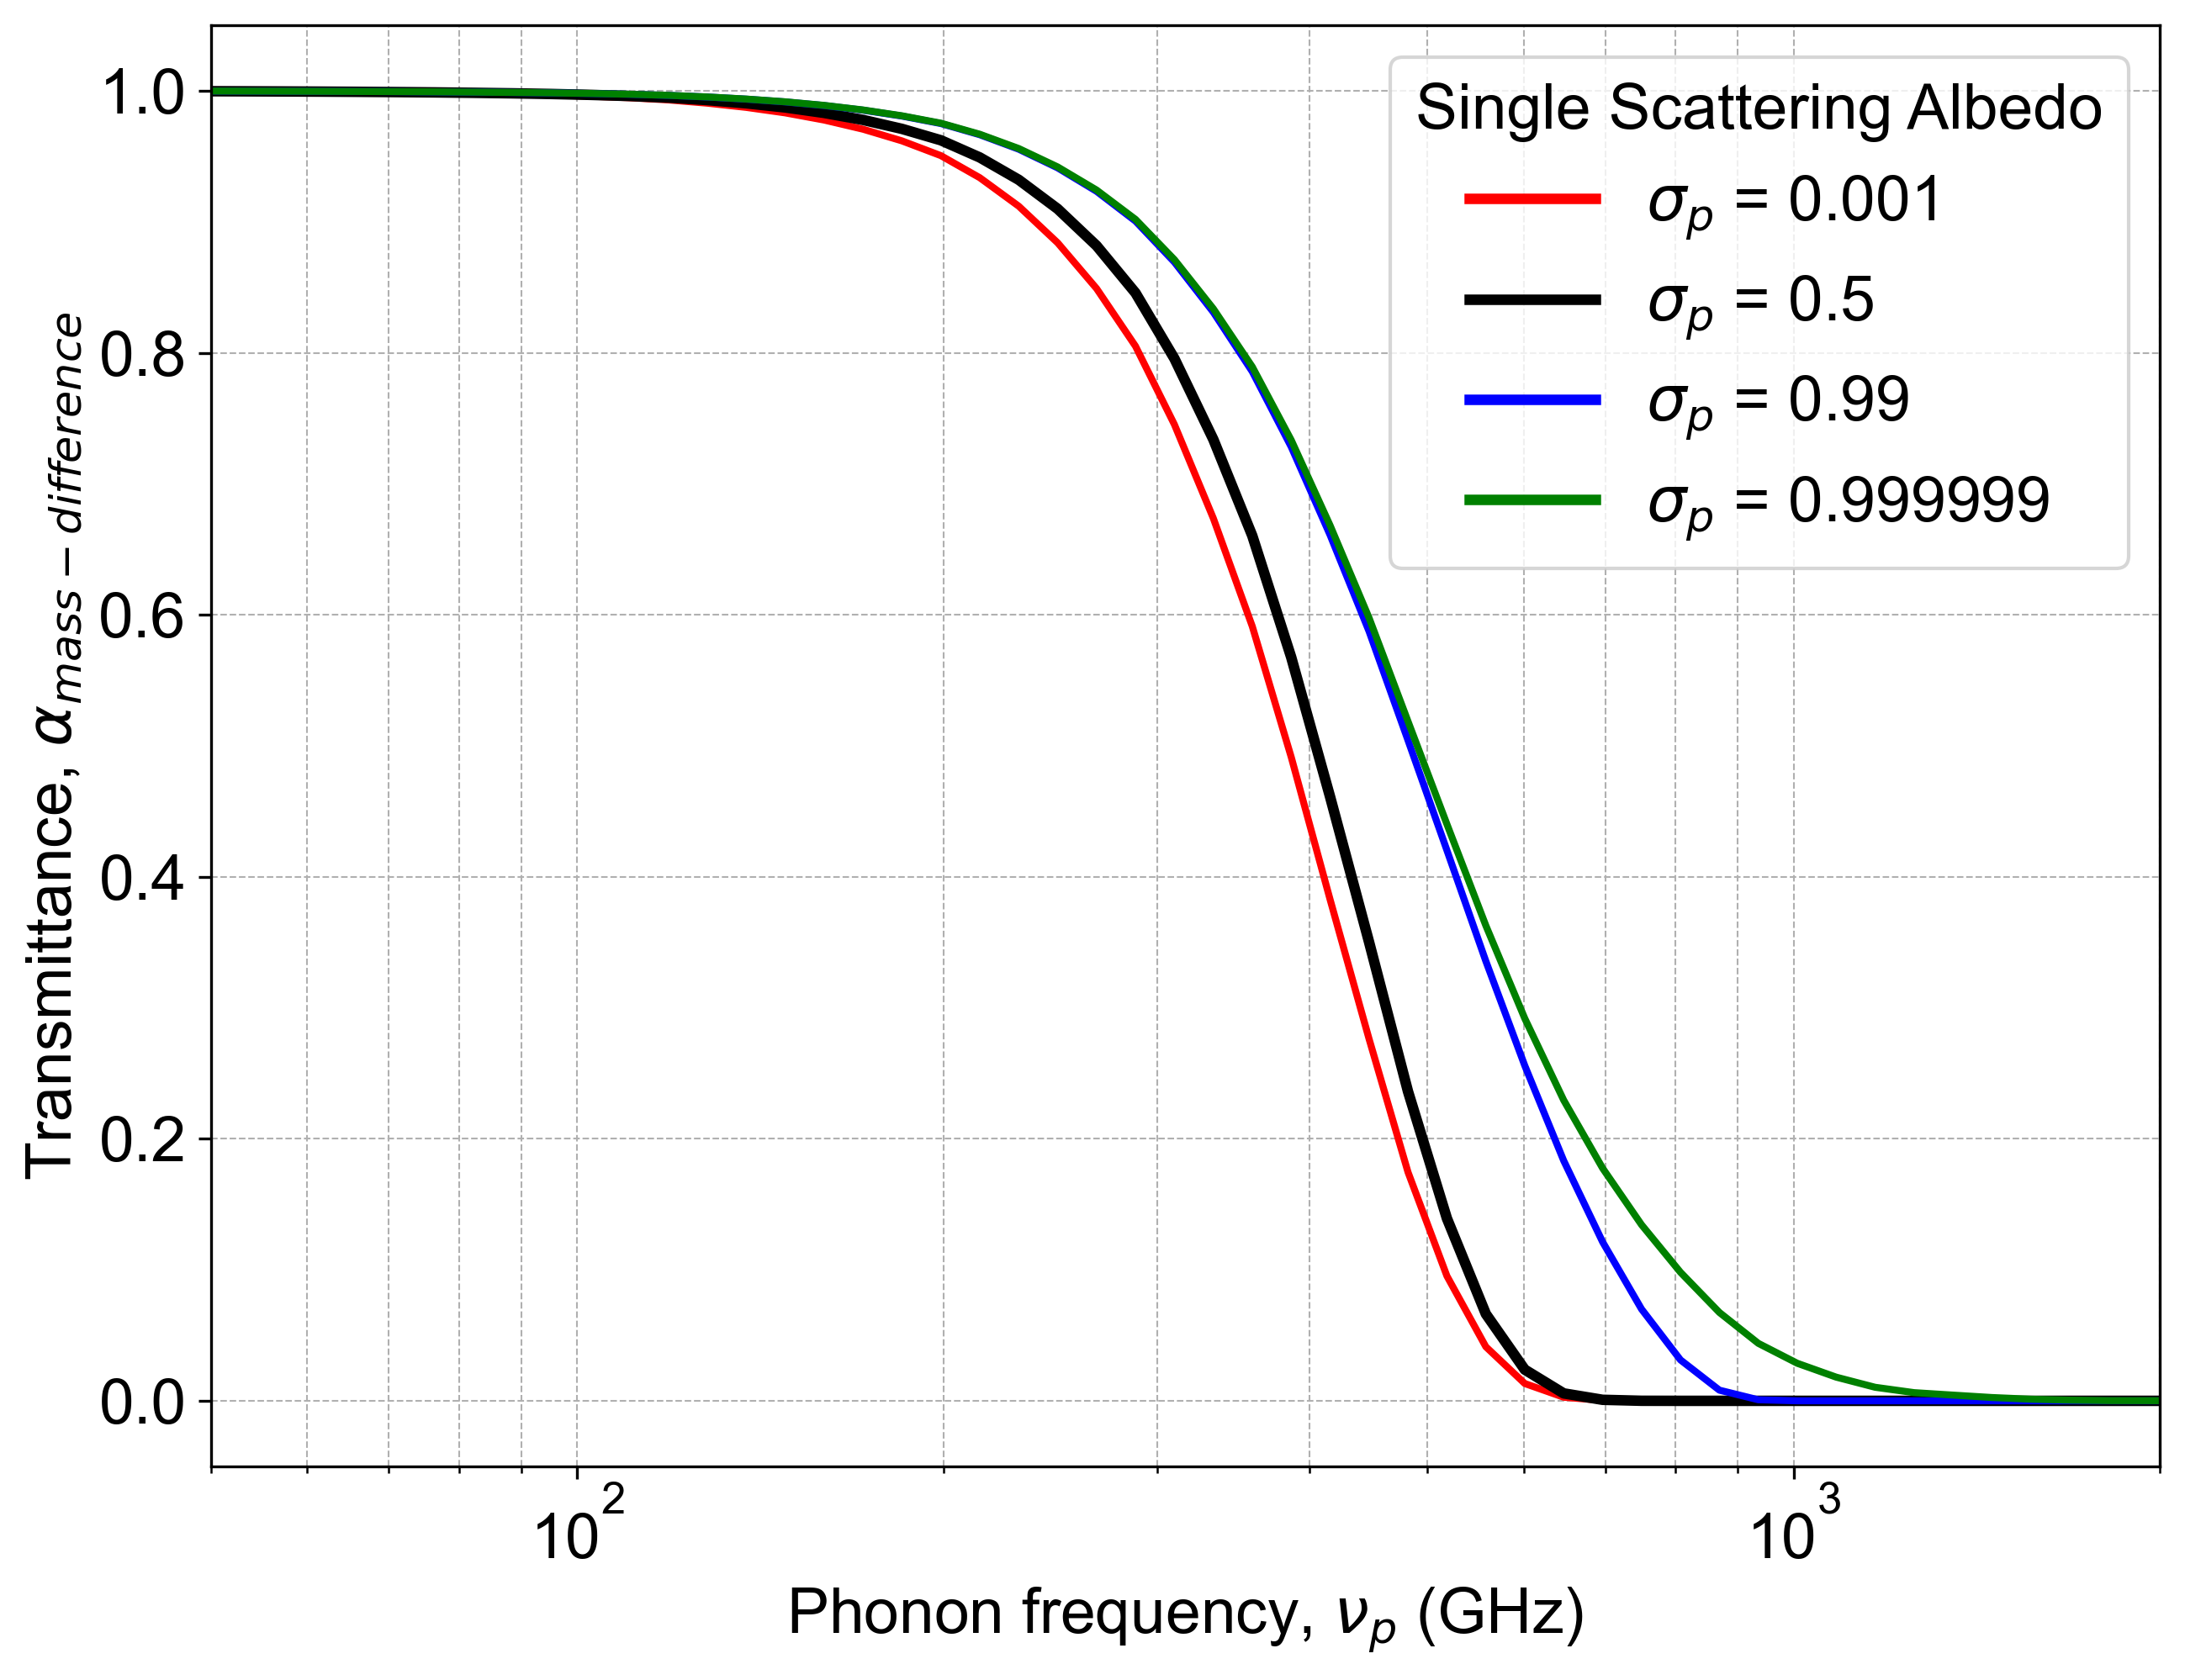

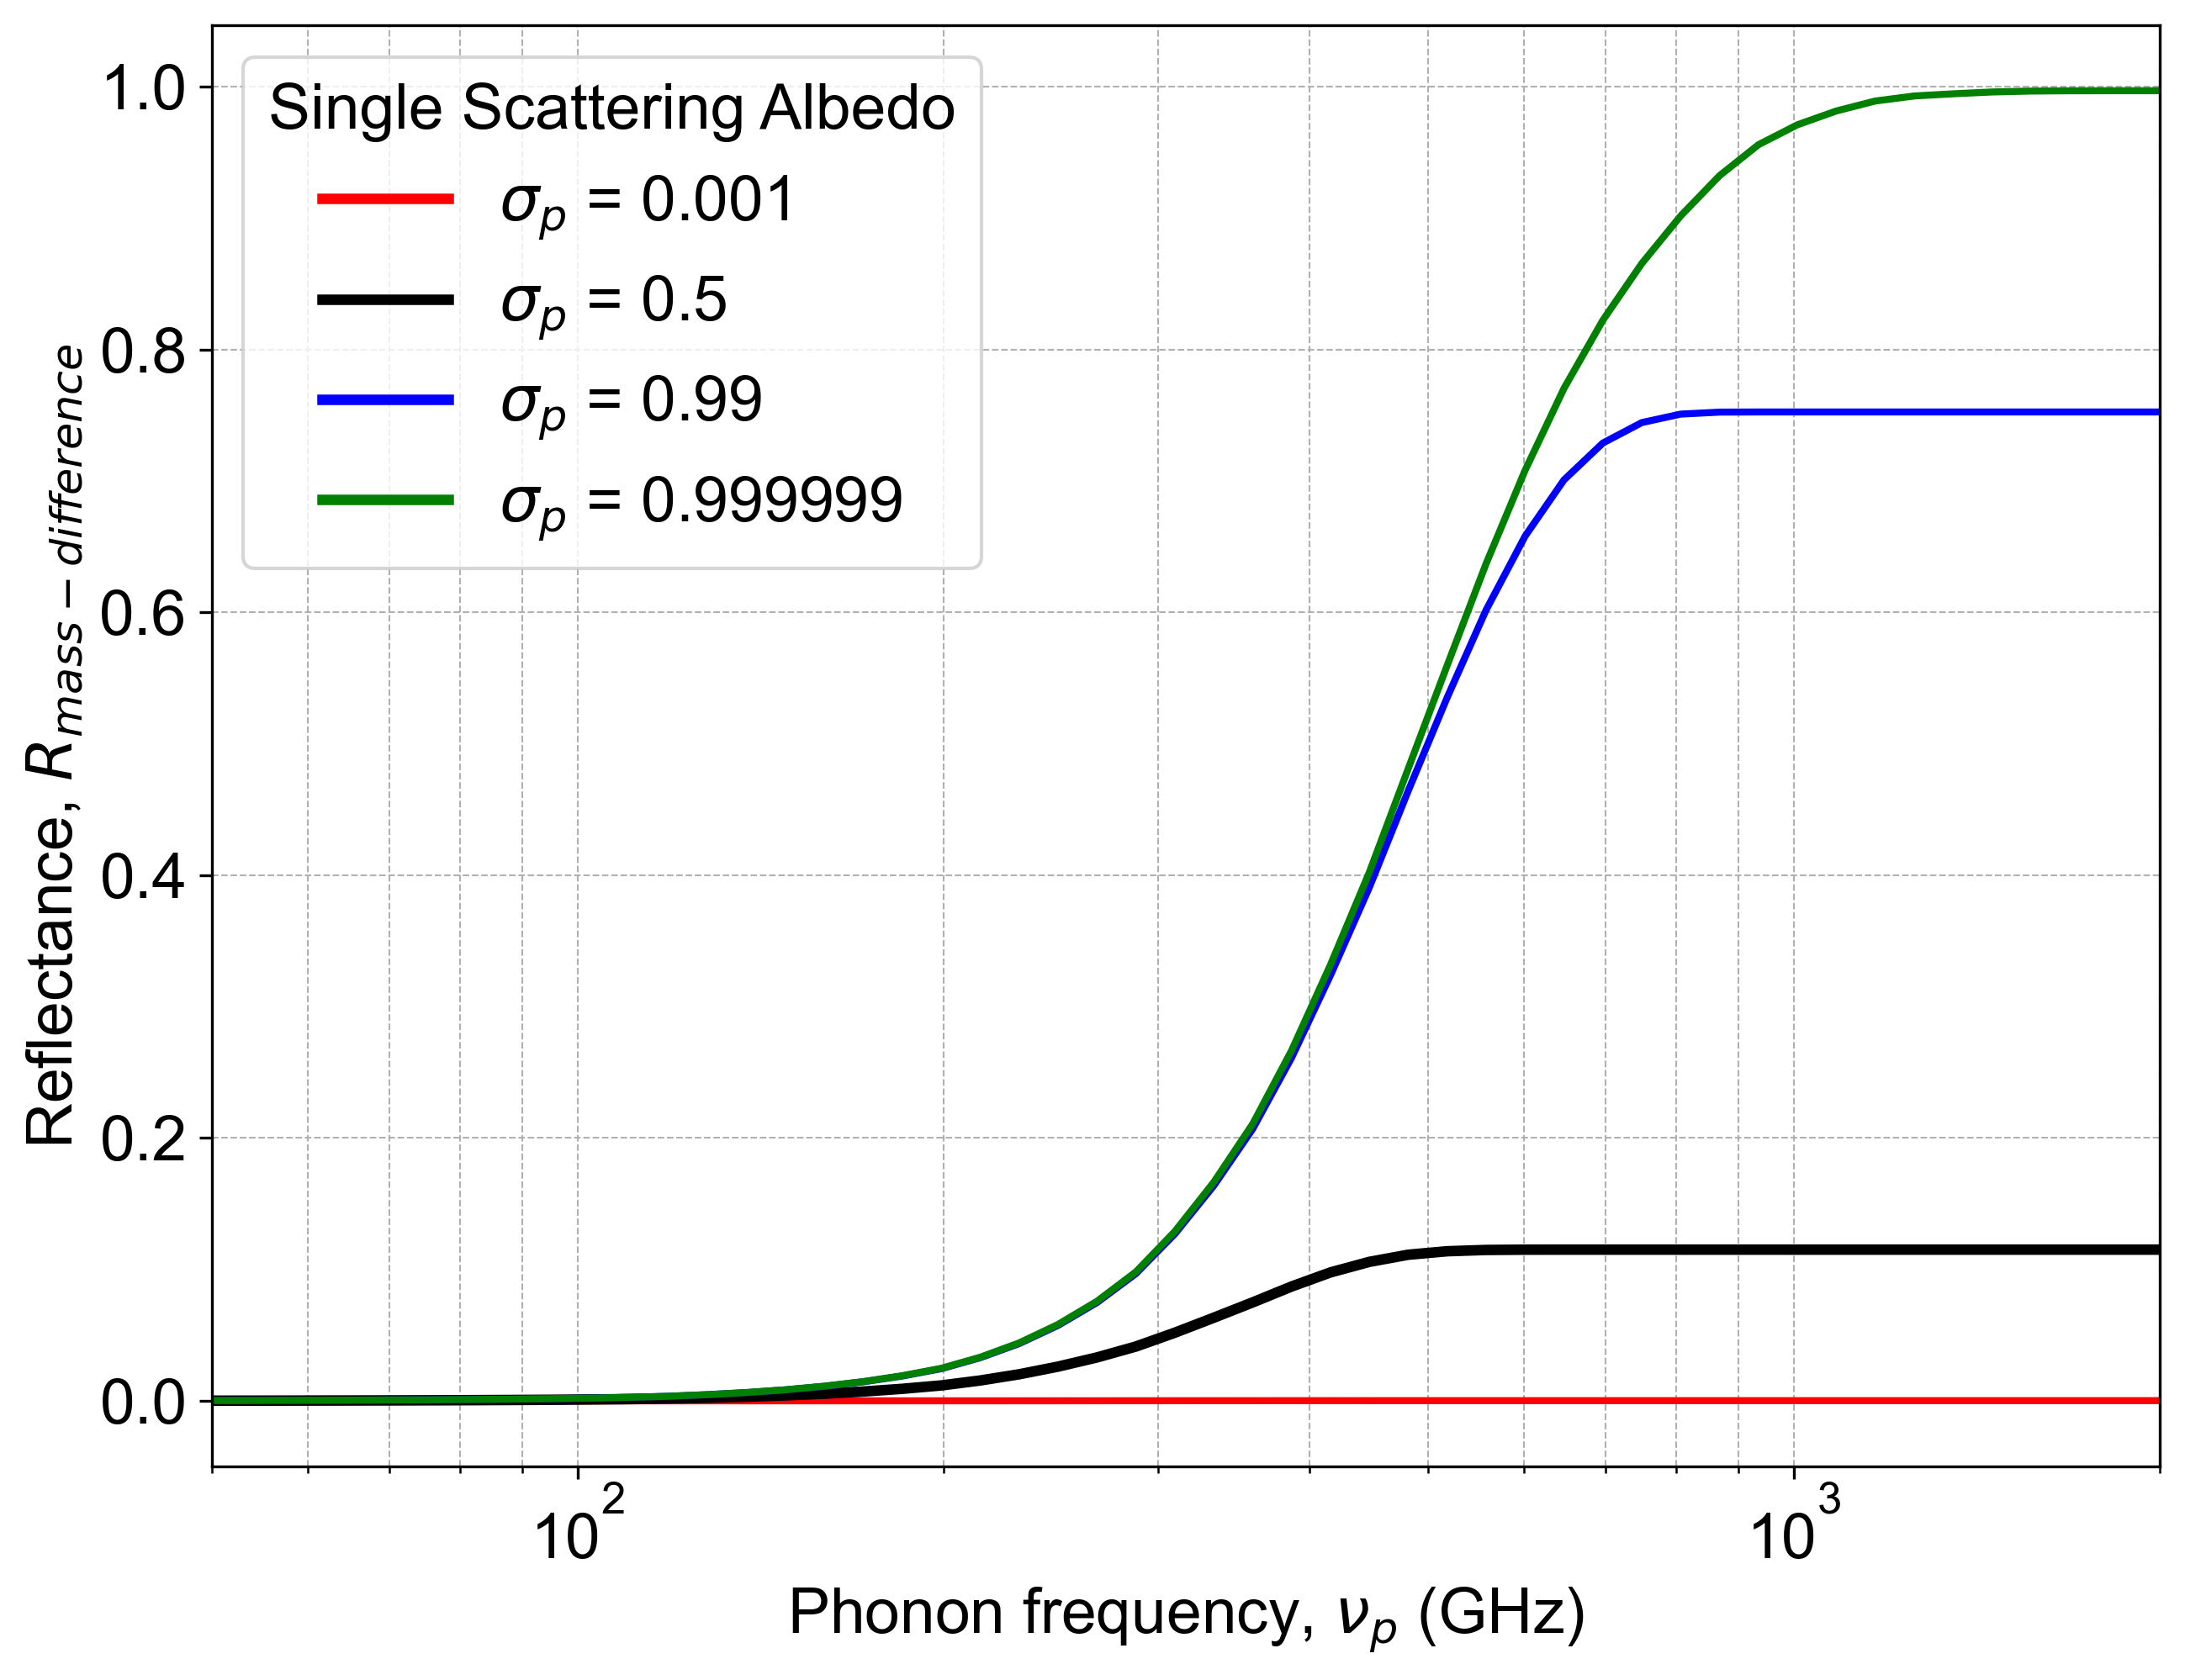

In [6]:
albedos = [0.001, 0.5, 0.99, 0.999999]
sweep = transport.flux_albedo_sweep(mfp_tr, albedos, mu0=1.0, L_um=1.0)
figures.figure4(nu_GHz, sweep, albedos, outdir=OUT, show=True)
figures.figureS9(nu_GHz, sweep, albedos, outdir=OUT, show=True);

## Figs. 5 and 6 — Single-interface transmission vs angle

Pure acoustic-mismatch interface transmission $\alpha(\cos\theta)$ for TA (solid)
and LA (dashed). The sharp cutoffs are the total-internal-reflection critical
angles for Snell refraction into the faster medium,
$\sin\theta_t=(c_2/c_1)\sin\theta_i$.

*Swartz & Pohl, Rev. Mod. Phys. **61**, 605 (1989).*

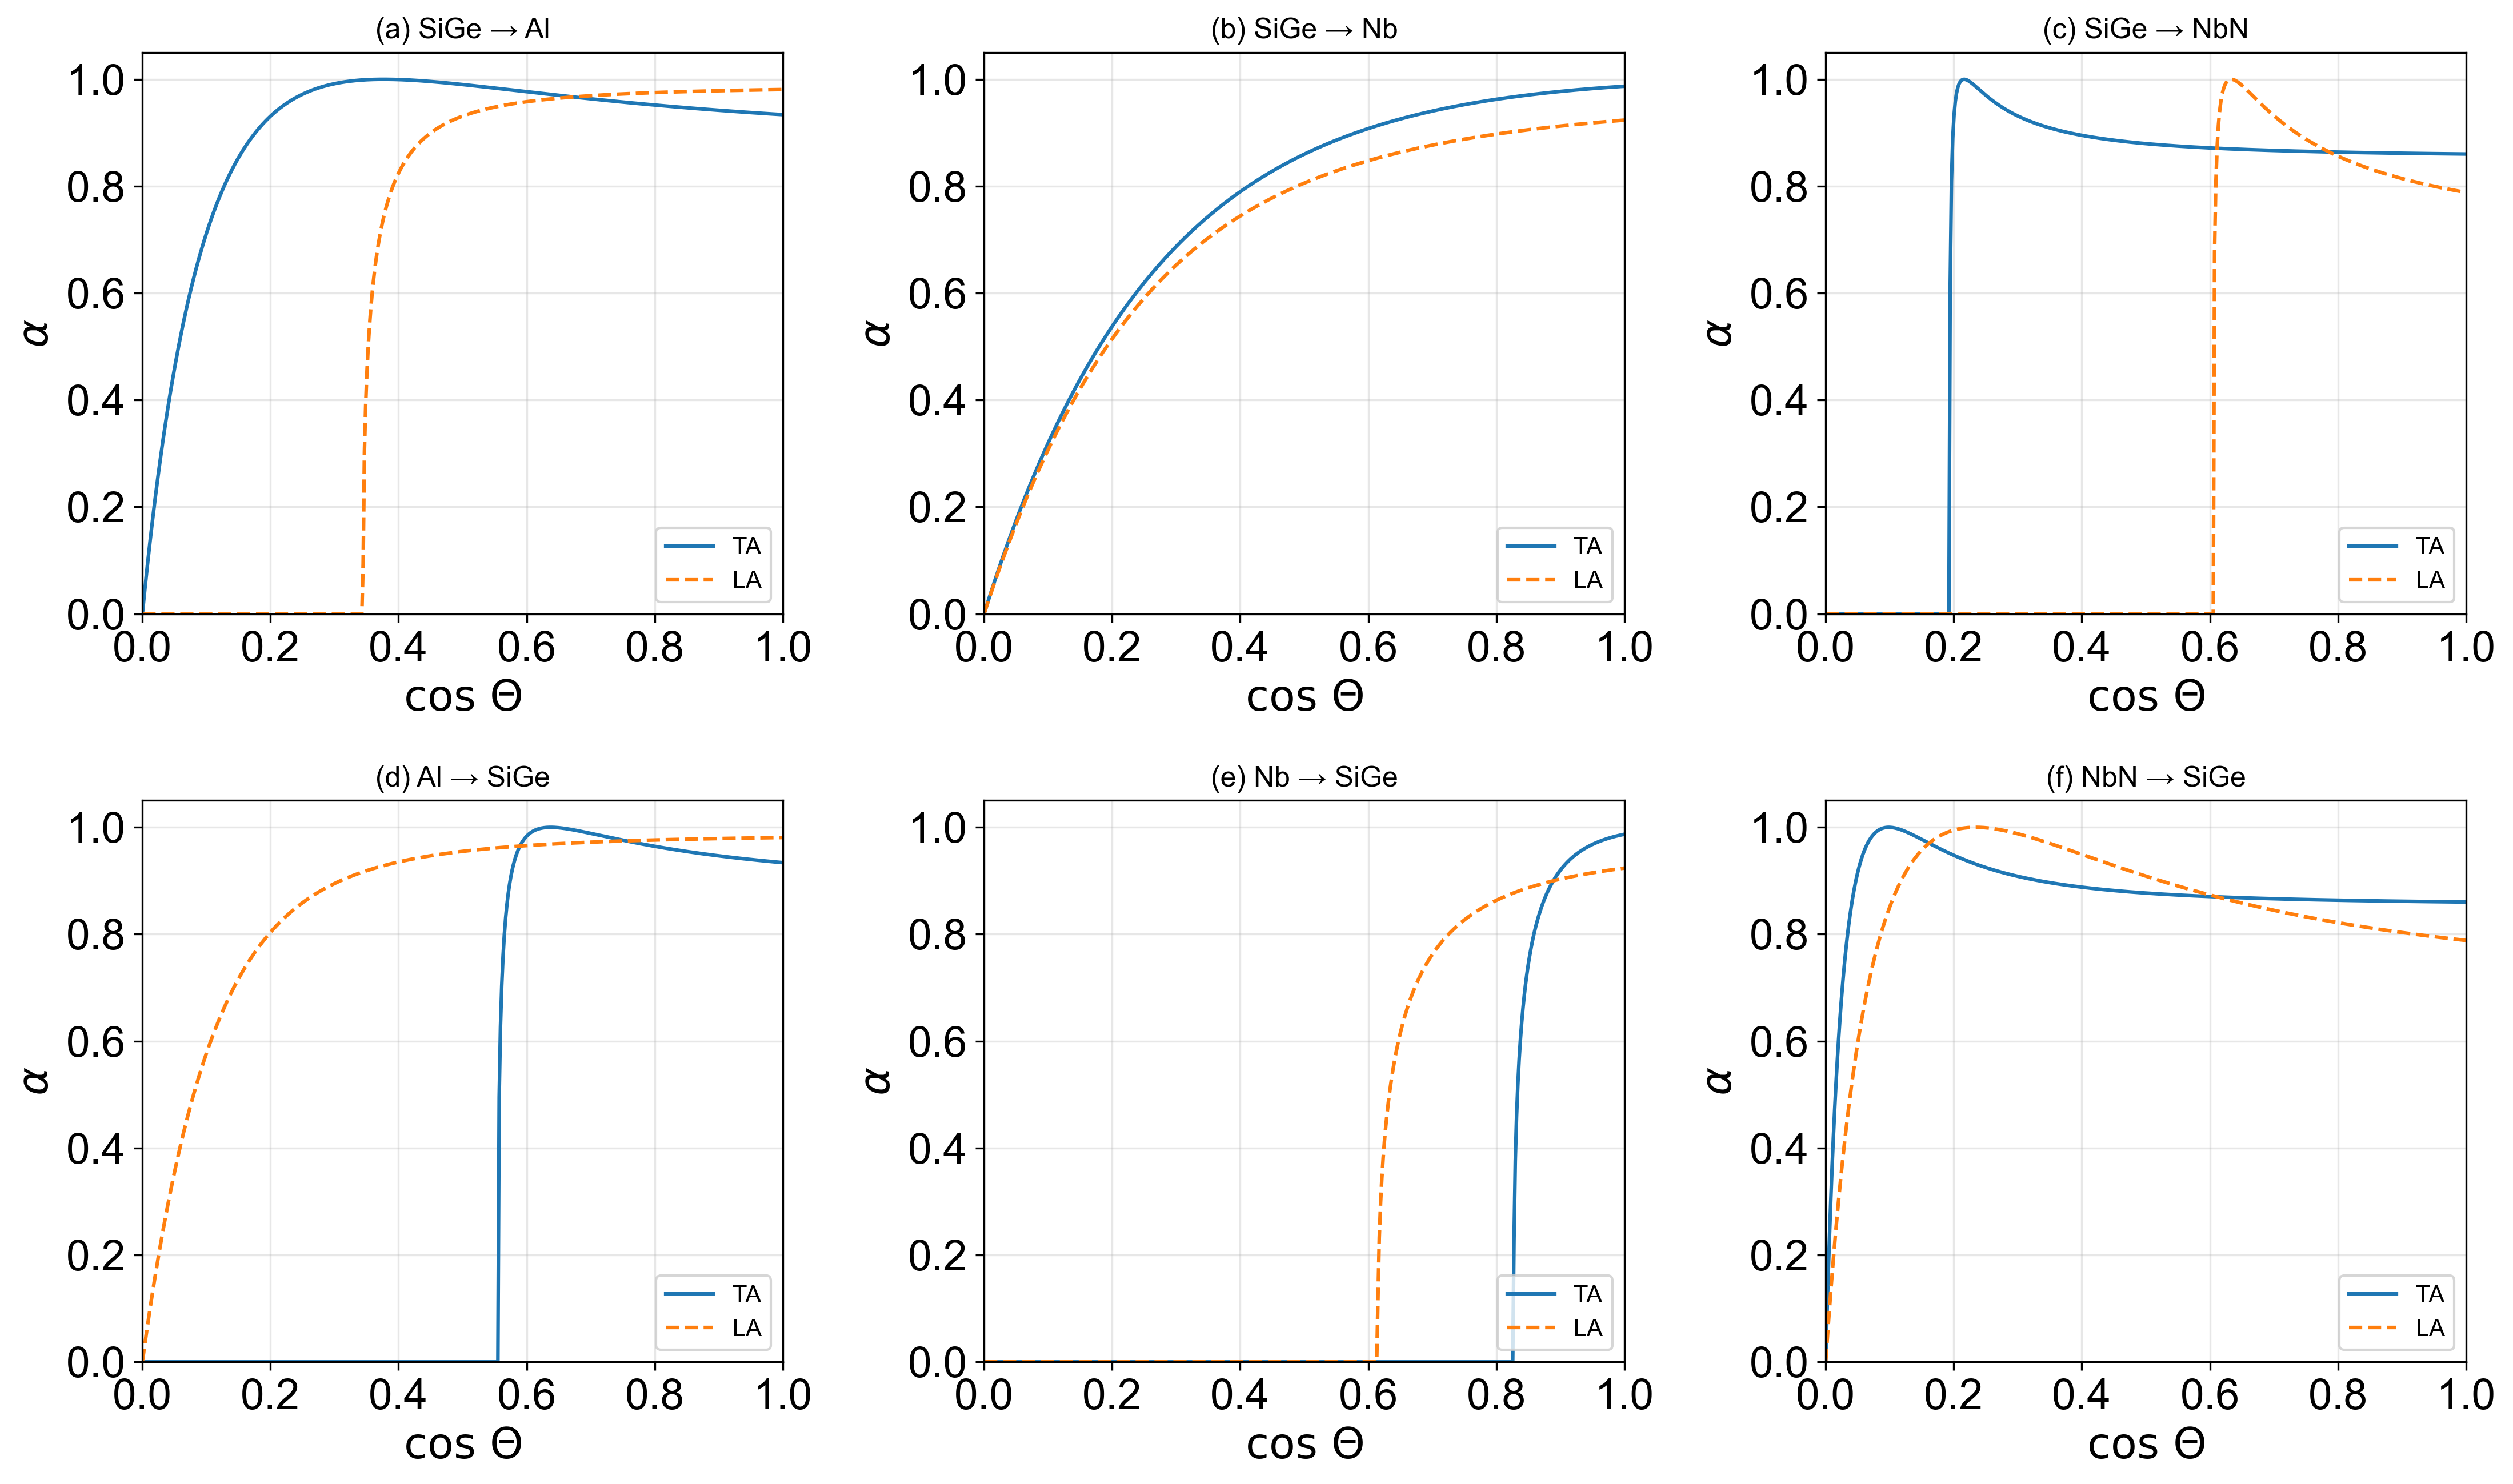

In [7]:
figures.figure5(pf.MATERIALS, outdir=OUT, show=True)    # Al-qubit interfaces

In [8]:
print(pf.MATERIALS)
Ab = pf.MATERIALS

{'Nb': {'rho': 8527, 'cL': 5080, 'cT': 2340}, 'NbN': {'rho': 8210, 'cL': 8090, 'cT': 4240}, 'Al': {'rho': 2710.0, 'cL': 6860.0, 'cT': 3460.0}, 'Si': {'rho': 2281.0, 'cL': 8210.0, 'cT': 5730.0}, 'SiGe_avg': {'rho': 3814.0, 'cL': 6440.0, 'cT': 4160.0}}


## Fig. S5 — Alloy mean free path vs composition

Tamura mass-difference scattering on an analytic **Born–von Kármán** density of
states gives the composition-dependent MFP for $\mathrm{Si}_{1-x}\mathrm{Ge}_x$ at
three frequencies. The BvK branch is $\omega(k)=\omega_0\sin(\tfrac{\pi}{2}k/k_0)$.

*Tamura, Phys. Rev. B **27**, 858 (1983); Born & von Kármán, Phys. Z. **13**, 297
(1912).*

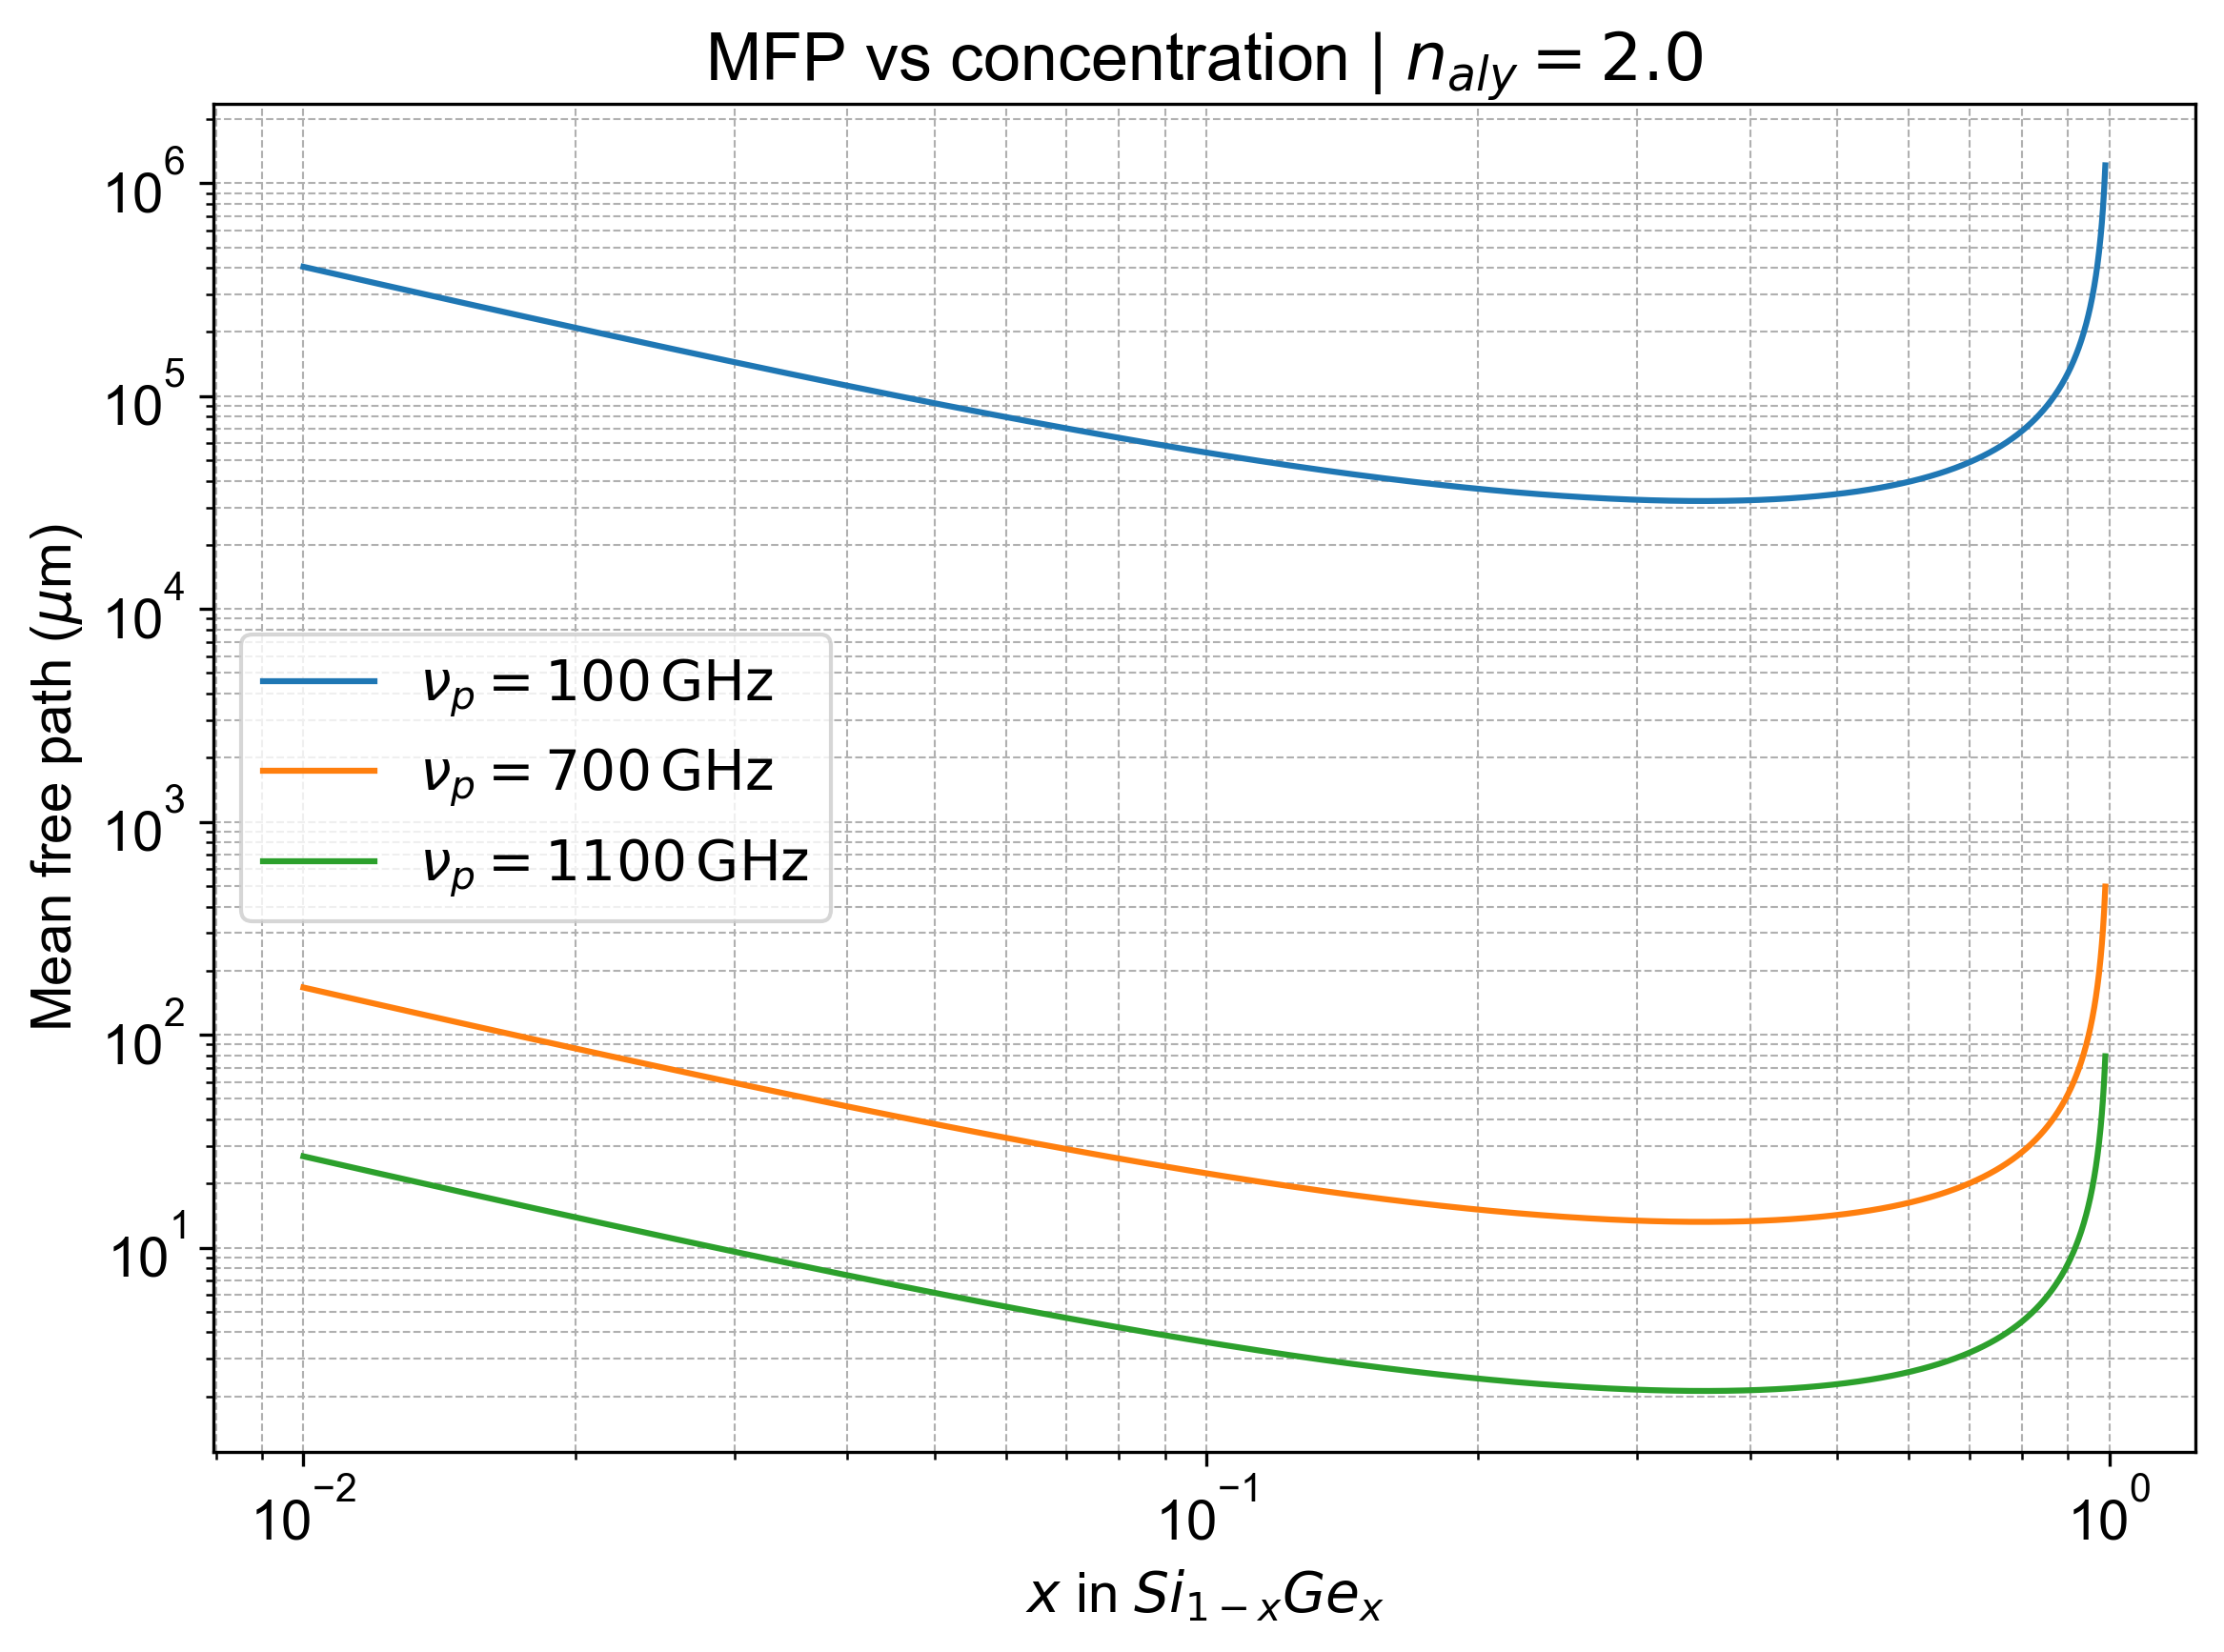

In [9]:
figures.figureS5('Silicon', 'Germanium', elemental, outdir=OUT,n_aly = 2.00, show=True);

## Fig. S6 — Debye specific-heat integrand

The dimensionless integrand $x^4 e^x/(e^x-1)^2$ (with $x=h\nu/k_B T_q$) and its
cumulative integral, approaching the Debye limit $4\pi^4/15\approx 25.98$, show
which phonon frequencies carry the heat capacity.

*Standard result; see Ashcroft & Mermin, Solid State Physics (1976), Ch. 23.*

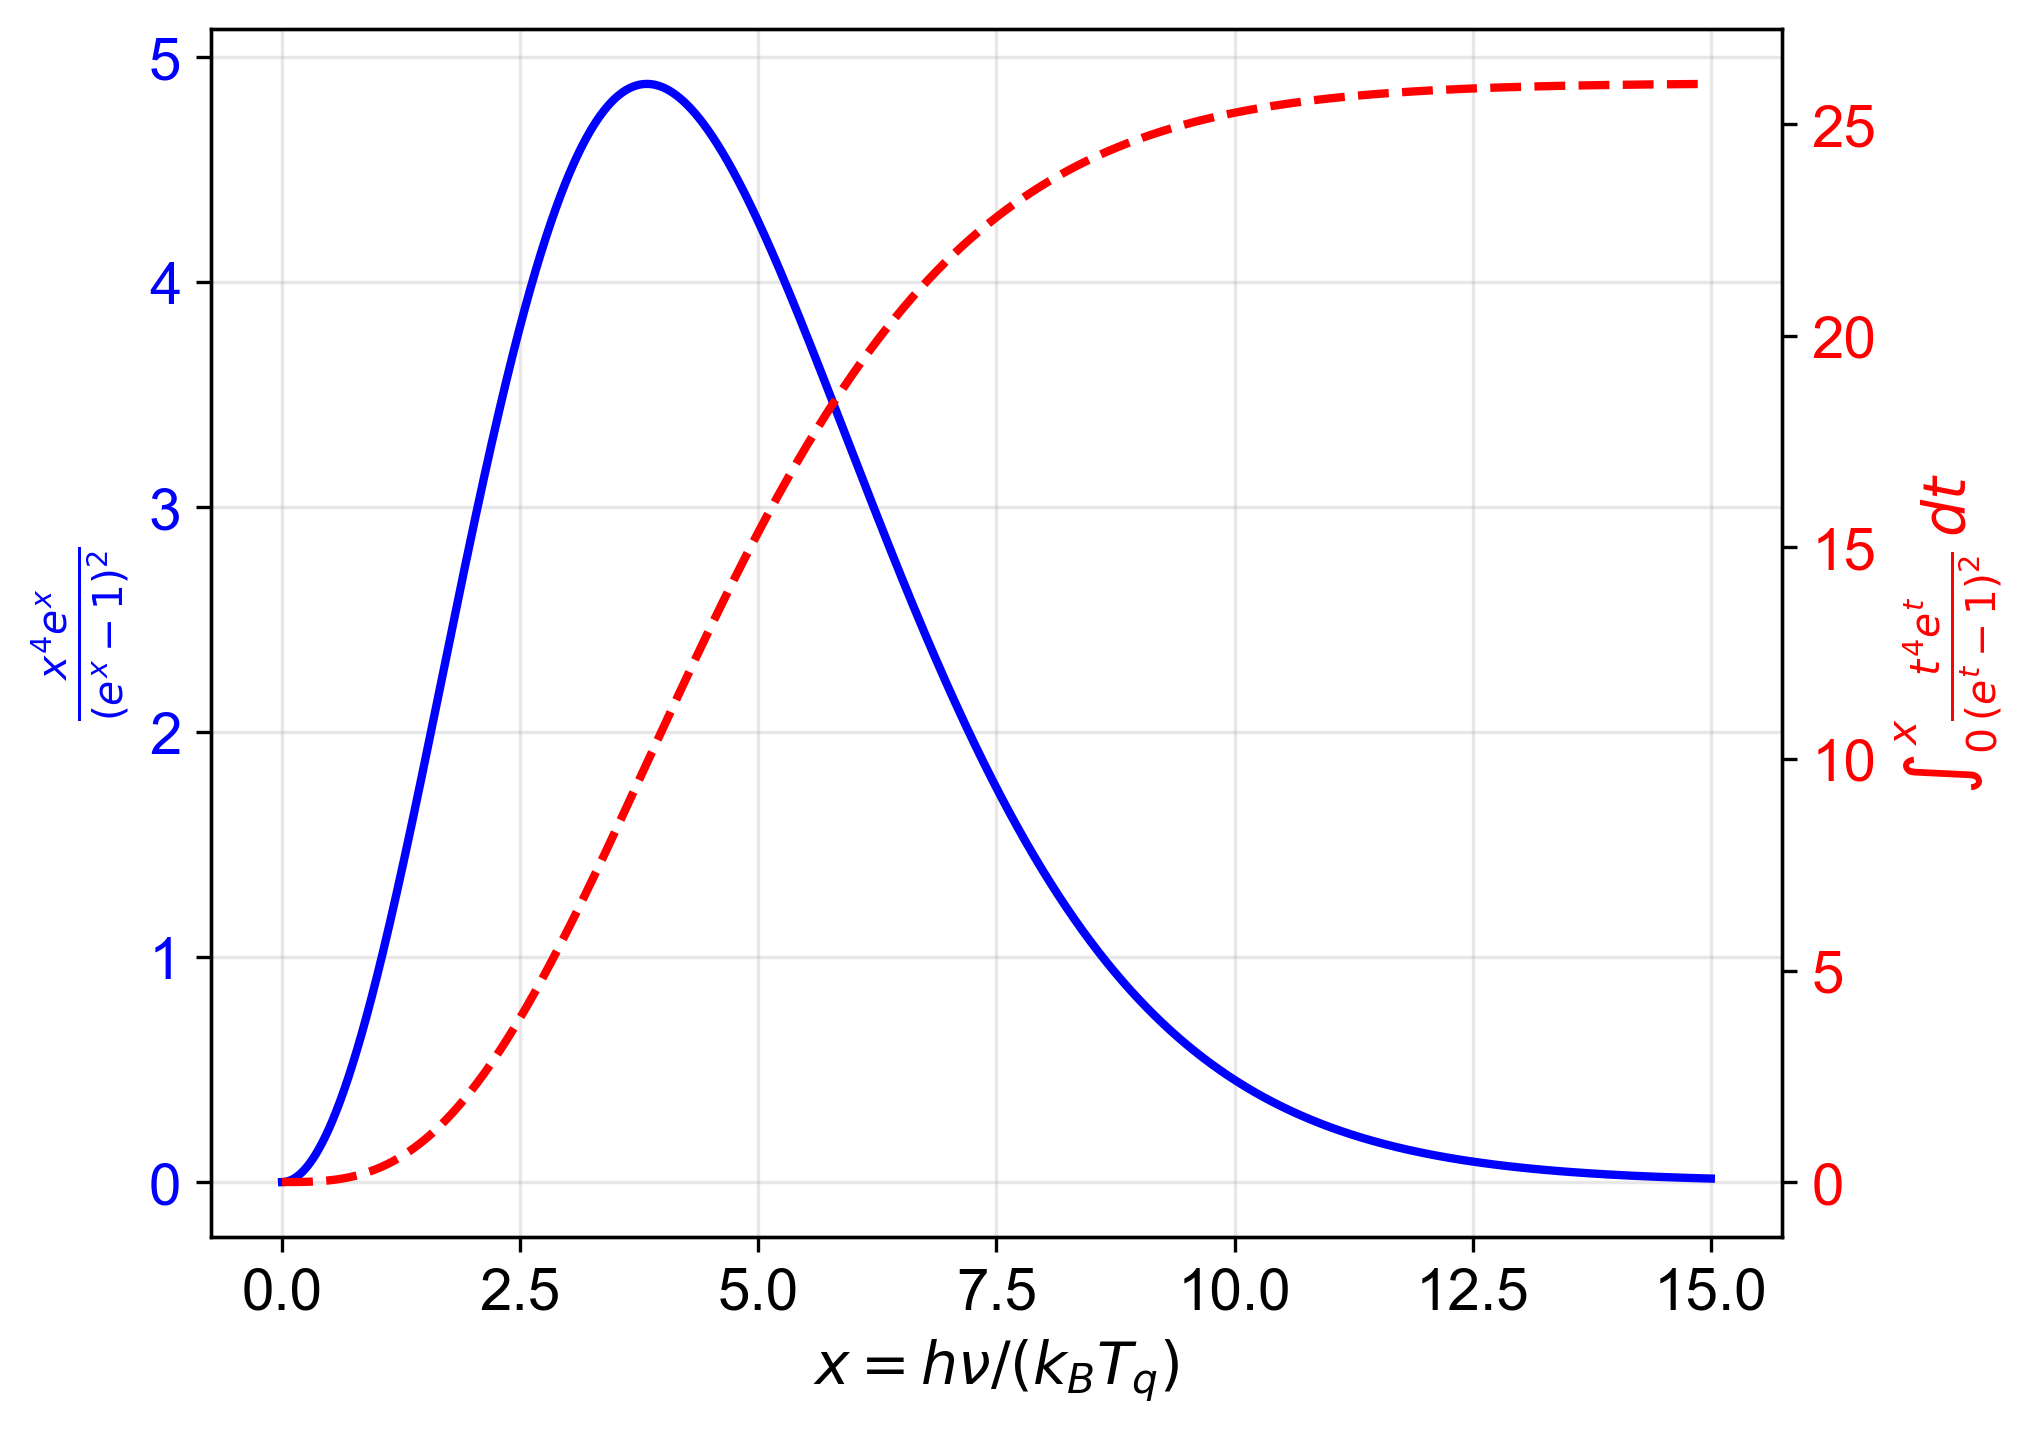

In [10]:
figures.figureS6(x_max=15.0, outdir=OUT, show=True);

## Fig. S7 — Broad alloy survey

Transmittance spectra for many solid-solution alloys at three thicknesses
(EPRT/DISORT, normal incidence). The vertical dashed lines mark the TA thermal
cutoff at 50 mK and the pair-breaking gap frequencies $2\Delta/h$ for Al
(85 GHz), Nb (750 GHz), and NbN (1693 GHz). This is the slowest cell (it solves
the transport equation for every alloy).

*Tamura, Phys. Rev. B **27**, 858 (1983); PythonicDISORT: Ho, JOSS **9**(103),
6442 (2024).*

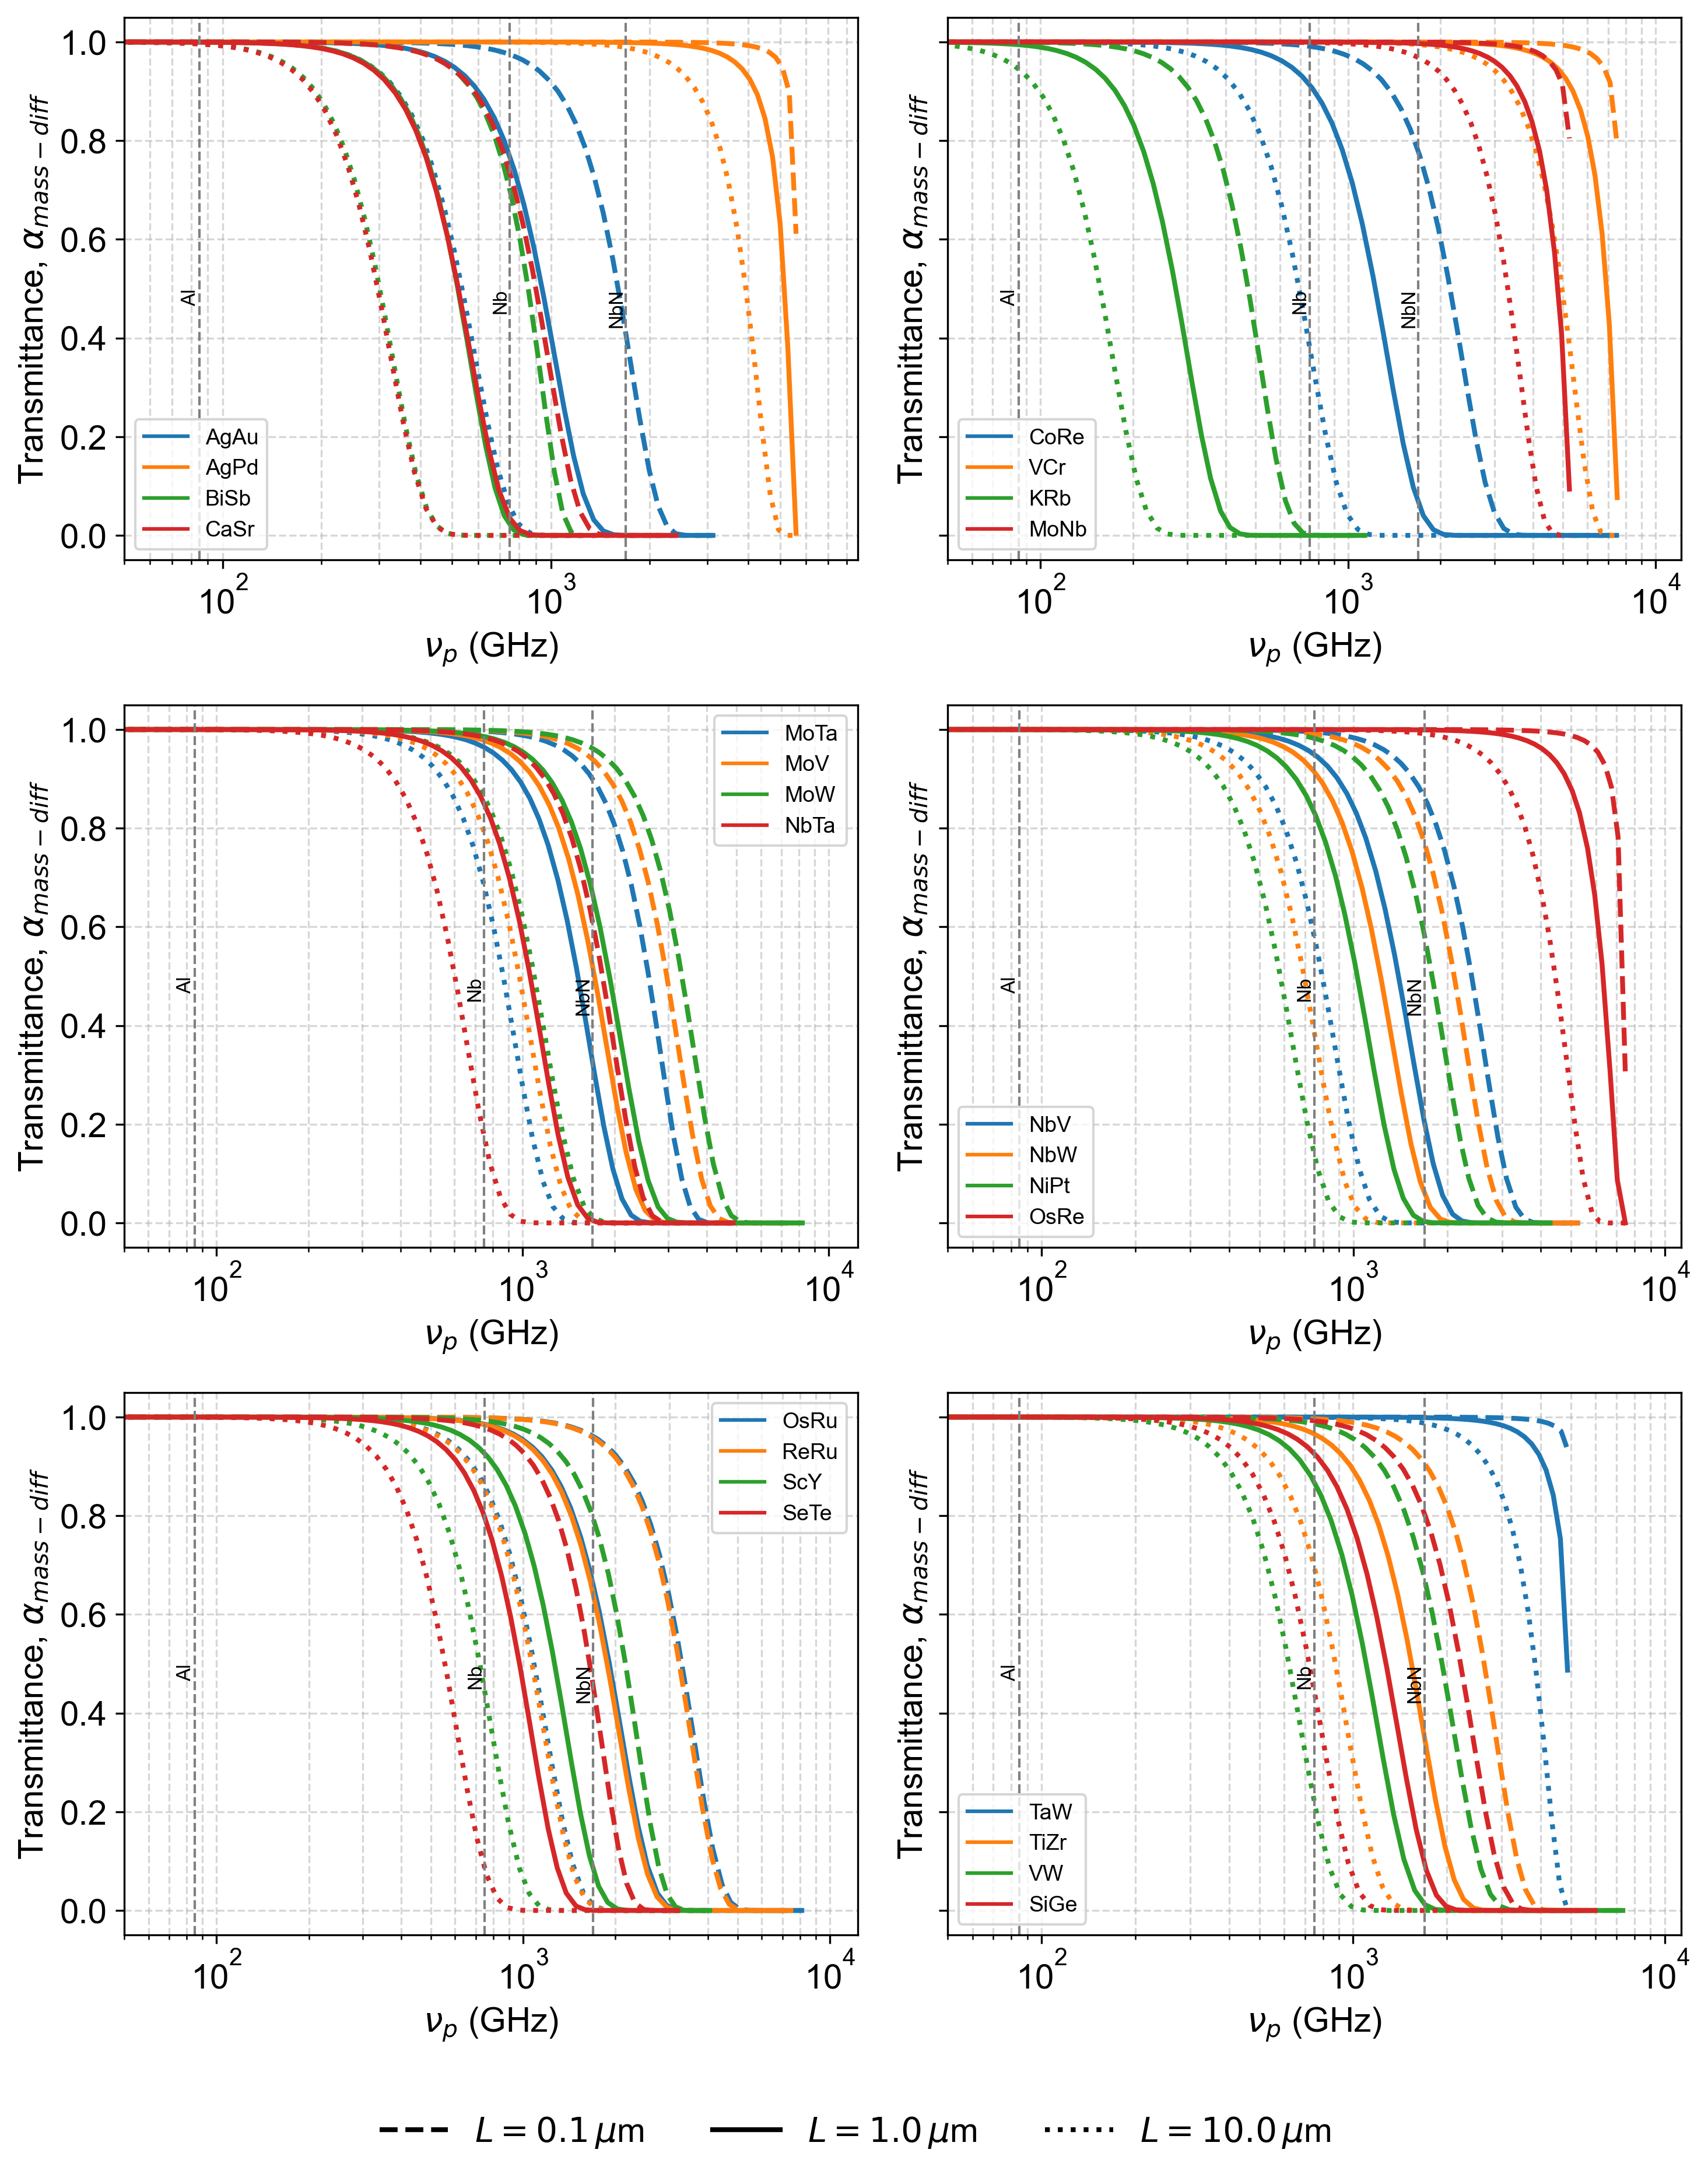

In [11]:
database = transport.alloy_transmittance_database(
    pf.FULLY_SOLUBLE_ALLOYS, elemental, [0.1, 1.0, 10.0], ssa=0.5, n_aly=2.00)
figures.figureS7(database, pf.FULLY_SOLUBLE_ALLOYS, [0.1, 1.0, 10.0], outdir=OUT, show=True);

## Fig. S8 — Component fluxes vs optical/acoustic depth

Diffuse-reflected ($F_u$), diffuse-transmitted ($F_d$), and direct ($F_s$)
fluxes, plus the reflectance and transmittance, vs the dimensionless optical
depth $\tau_p=L/\Lambda$, from the EPRT/DISORT slab solution.

*EPRT: Majumdar, J. Heat Transfer **115**, 7 (1993); Prasher, Appl. Phys. Lett.
**83**, 48 (2003).*

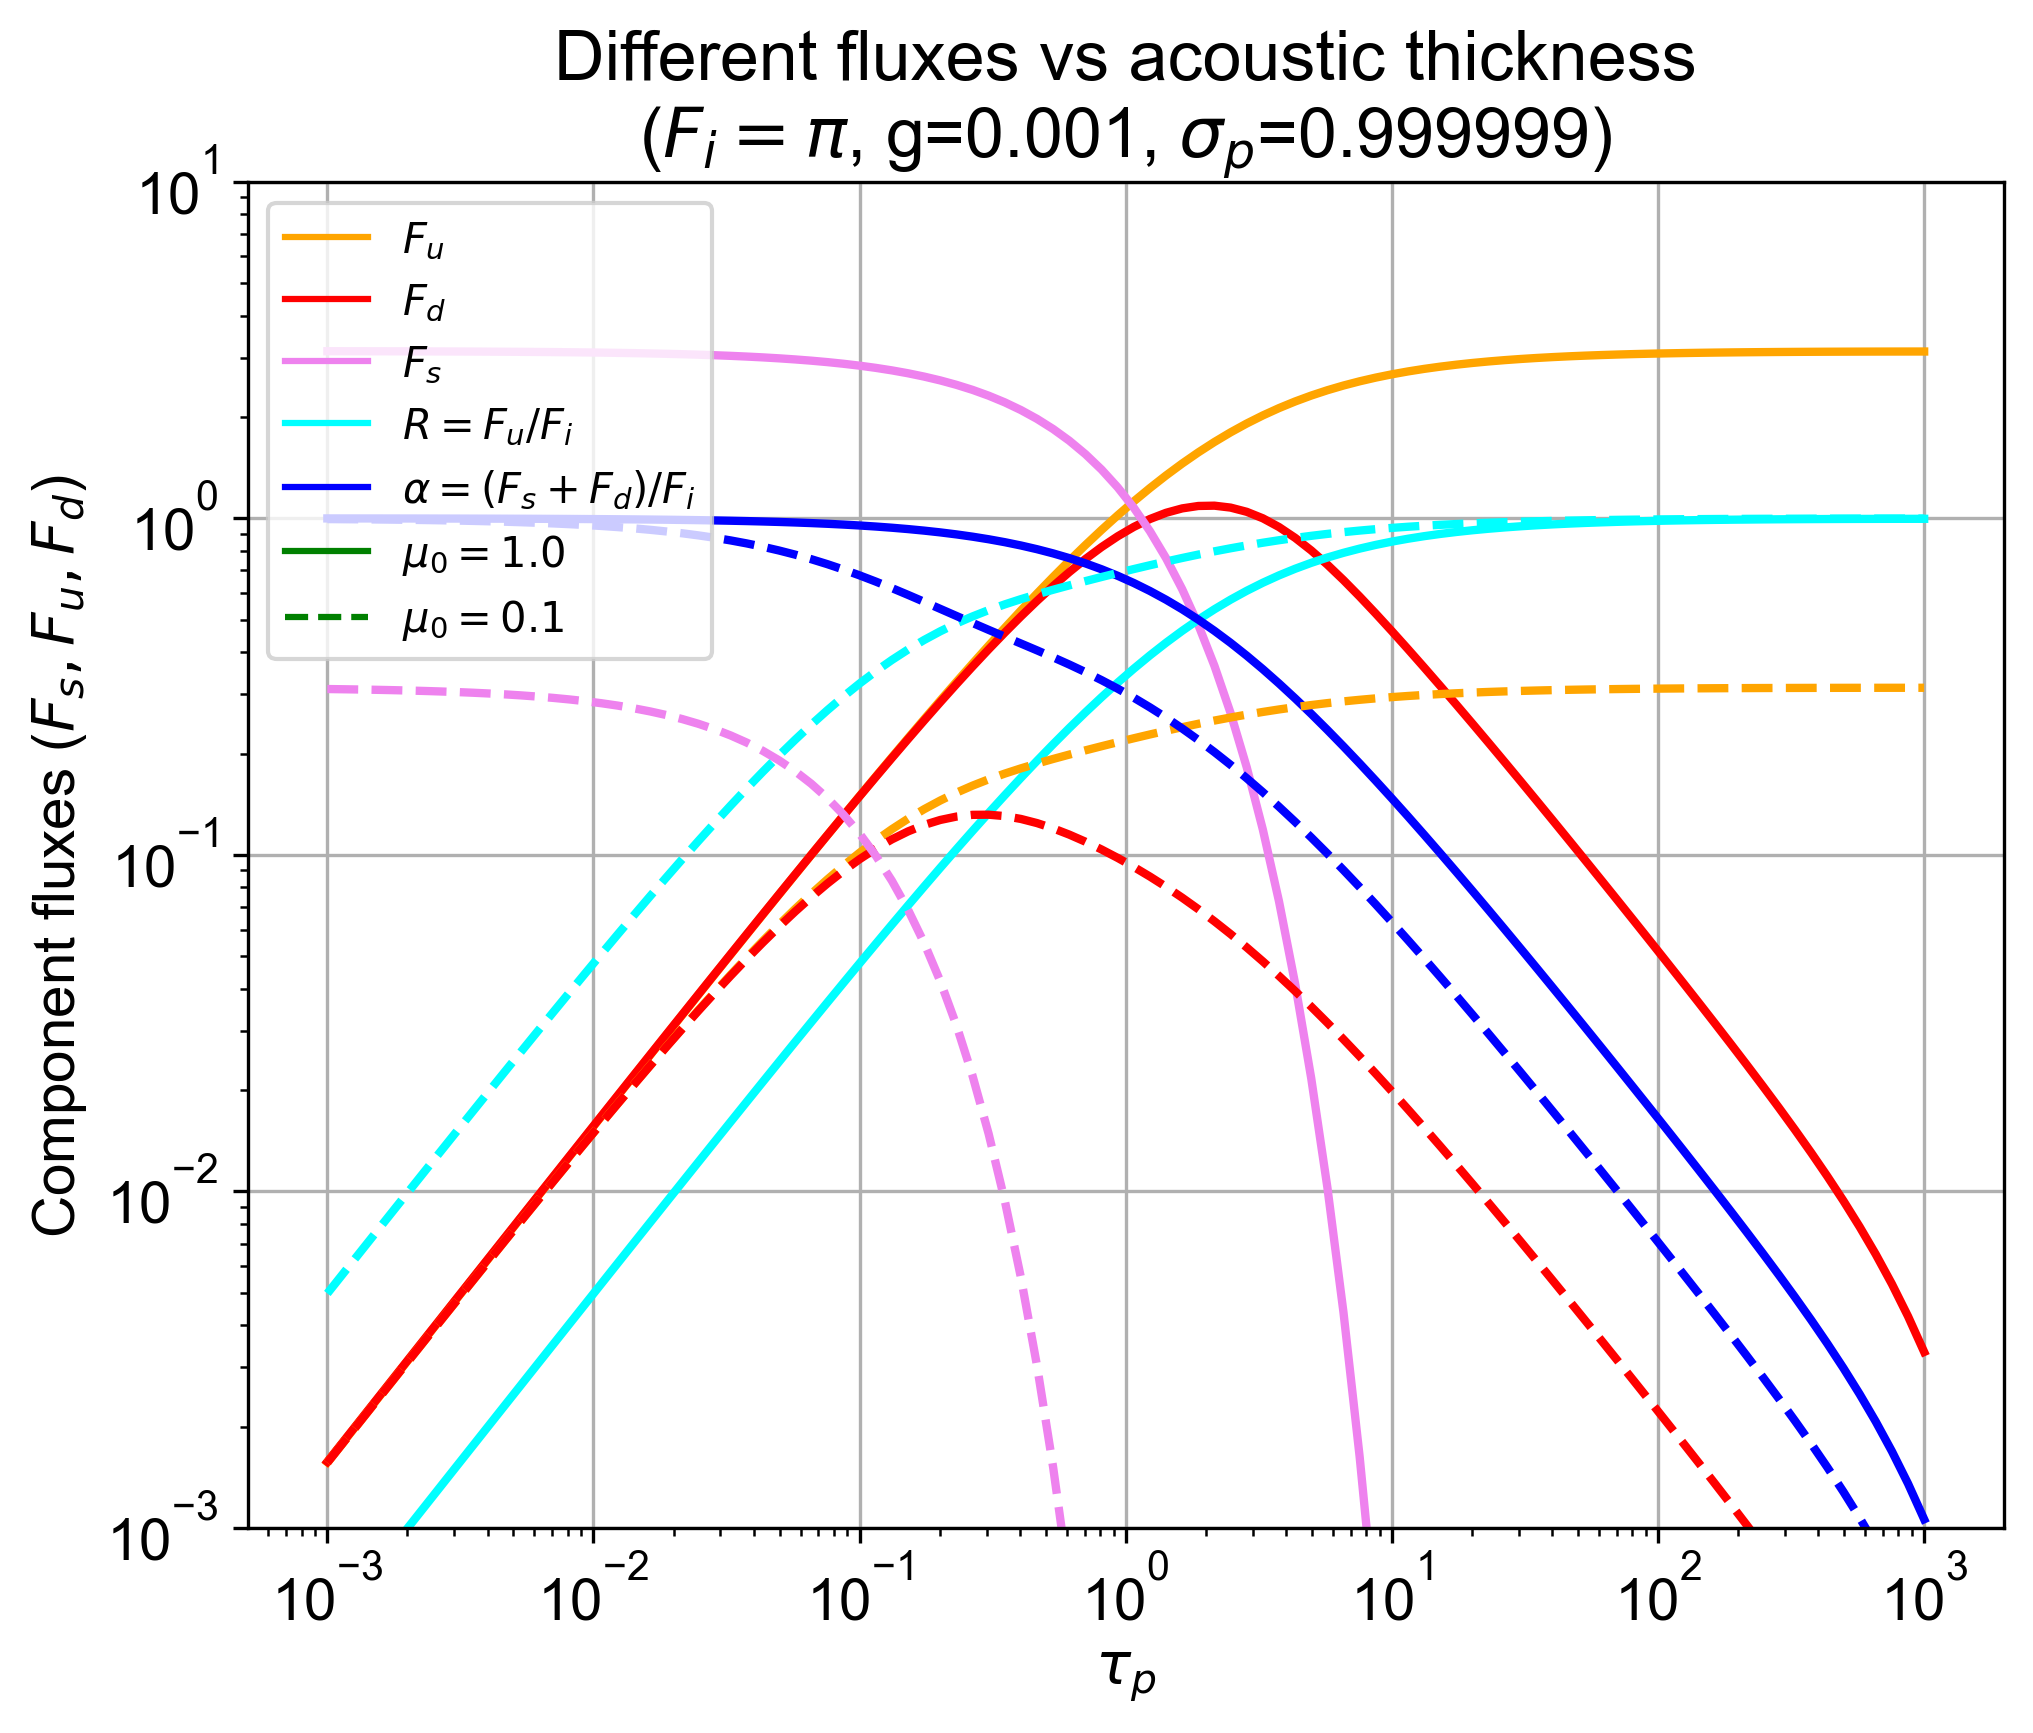

In [12]:
tau = np.logspace(-3, 3, 100)
fluxes = transport.flux_vs_thickness(tau, (1.0, 0.1), ssa=0.999999)
figures.figureS8(tau, fluxes ,outdir=OUT, show=True);